# <font color = Green> _Portfolio Management Analysis for Ms. Alexandra Kolishnyick_

----------------

This project provides a comprehensive analysis for constructing and managing an investment portfolio for a conservative, long-term investor, Ms. Alexandra Kolishnyick. The objective is to design a robust portfolio that prioritises capital preservation and stable, moderate growth to meet her goal of funding an NGO post graduation.

---------------------

## <font color = Dark> _1. Preliminary Steps_

Before moving to EDA and analysis, we must prepare the dataset in a structured way.  
The following steps outline the process:

1. **Import Libraries**
2. **Load Stock CSVs (12 Companies)**  
3. **Merge all 12 stock files, Annexure and  S&P500** 
4. **Data Cleaning & Formatting**
5. **Final Dataset for download**

In [7]:
# Importing Libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# File path
path = "/Users/lakshmisagarsp/Documents/Personal/Capstone/Captone_Data_Set/All_stocks/"

# Getting a list of all CSV files
all_files = glob.glob(os.path.join(path, "*.csv"))

dataframes = []

for file in all_files:
    df = pd.read_csv(file)
    
    # Adding ticker column to merge with Annexure later on
    ticker = os.path.basename(file).replace(".csv", "")
    df["Ticker"] = ticker

    dataframes.append(df)
    print(f"Loaded file: {os.path.basename(file)} | Shape: {df.shape}")

# Merging all stock dataframes
all_stocks = pd.concat(dataframes, ignore_index=True)

print("\nAll stock files merged.")
print(f"Final dataframe shape: {all_stocks.shape}")

# Loading Annexure
annexure = pd.read_csv("/Users/lakshmisagarsp/Documents/Personal/Capstone/Captone_Data_Set/Annexure-I.csv")

# Adding company and industry
stock_analysis_dataset_raw = all_stocks.merge(annexure, on="Ticker", how="left")

# Keeping only required columns. We will use only Adj_close as it indicates real returns after factoring in dividend payouts, etc.
stock_analysis_dataset_raw = stock_analysis_dataset_raw[["Date", "Ticker", "Company Name", "Industry", "Adj Close", "Volume"]]

# Converting the date column to date format
stock_analysis_dataset_raw["Date"] = pd.to_datetime(stock_analysis_dataset_raw["Date"], dayfirst=True, errors="coerce")

# Loading the S&P500 index and merging it to create one final dataset for analysis
sp500 = pd.read_csv("/Users/lakshmisagarsp/Documents/Personal/Capstone/Captone_Data_Set/S&P500.csv")
sp500["Date"] = pd.to_datetime(sp500["Date"], dayfirst=True, errors="coerce")

stock_analysis_dataset_raw = stock_analysis_dataset_raw.merge(
    sp500[["Date", "Adj Close"]].rename(columns={"Adj Close": "SP500_Adj_Close"}),
    on="Date", how="left")

stock_analysis_dataset_raw.head()

Loaded file: CS.csv | Shape: (2712, 8)
Loaded file: MRK.csv | Shape: (2525, 8)
Loaded file: HA.csv | Shape: (2524, 8)
Loaded file: DB.csv | Shape: (2712, 8)
Loaded file: AMZN.csv | Shape: (2524, 8)
Loaded file: GS.csv | Shape: (2712, 8)
Loaded file: BHC.csv | Shape: (2525, 8)
Loaded file: ALK.csv | Shape: (2524, 8)
Loaded file: AAL.csv | Shape: (2517, 8)
Loaded file: GOOG.csv | Shape: (2524, 8)
Loaded file: AAPL.csv | Shape: (2517, 8)
Loaded file: JNJ.csv | Shape: (2525, 8)

All stock files merged.
Final dataframe shape: (30841, 8)


,Date,Ticker,Company Name,Industry,Adj Close,Volume,SP500_Adj_Close
0,2010-01-04,CS,Credit Suisse,Finance,34.852165,734200.0,NaN
1,2010-01-05,CS,Credit Suisse,Finance,35.140423,447700.0,NaN
2,2010-01-06,CS,Credit Suisse,Finance,34.651054,751200.0,NaN
3,2010-01-07,CS,Credit Suisse,Finance,36.052116,833700.0,NaN
4,2010-01-08,CS,Credit Suisse,Finance,36.581703,706900.0,NaN


### Data formatting and Cleaning

In [10]:
# Let's get a look at the data and some of its attributes

pd.set_option("display.max_columns", None)
print("Rows:", stock_analysis_dataset_raw.shape[0])
print("Columns:", stock_analysis_dataset_raw.shape[1])
print("\nFirst 10 rows and all columns:\n")
stock_analysis_dataset_raw.head(10)

Rows: 30841
Columns: 7

First 10 rows and all columns:



,Date,Ticker,Company Name,Industry,Adj Close,Volume,SP500_Adj_Close
0,2010-01-04,CS,Credit Suisse,Finance,34.852165,734200.0,NaN
1,2010-01-05,CS,Credit Suisse,Finance,35.140423,447700.0,NaN
2,2010-01-06,CS,Credit Suisse,Finance,34.651054,751200.0,NaN
3,2010-01-07,CS,Credit Suisse,Finance,36.052116,833700.0,NaN
4,2010-01-08,CS,Credit Suisse,Finance,36.581703,706900.0,NaN
5,2010-01-11,CS,Credit Suisse,Finance,36.253220,537700.0,NaN
6,2010-01-12,CS,Credit Suisse,Finance,35.690117,405800.0,NaN
7,2010-01-13,CS,Credit Suisse,Finance,35.750450,423200.0,NaN
8,2010-01-14,CS,Credit Suisse,Finance,35.777260,339700.0,NaN
9,2010-01-15,CS,Credit Suisse,Finance,33.947174,727200.0,NaN


In [11]:
# Checking for any zero or Negative values in the data set
numeric_cols = ["Adj Close", "Volume", "SP500_Adj_Close"]
stock_analysis_dataset_raw[numeric_cols] = stock_analysis_dataset_raw[numeric_cols].mask(stock_analysis_dataset_raw[numeric_cols] <=0)

# Rounding all values to 3 decimal places for simpler visualisations and understanding

stock_analysis_dataset_raw[numeric_cols] = stock_analysis_dataset_raw[numeric_cols].round(3)

In [12]:
# Missing values function
def missing_values(df):
    missing_total = df.isnull().sum().sort_values(ascending = False) 
    missing_percent = ((df.isnull().sum()/df.shape[0]) *100).sort_values(ascending = False)
    data_type = df.dtypes
    M = pd.concat([missing_total, missing_percent, data_type], axis=1, keys=["Missing Total", "Missing Percentage", "Data Type"])
    return M

In [13]:
missing_values(stock_analysis_dataset_raw)

,Missing Total,Missing Percentage,Data Type
SP500_Adj_Close,637,2.065432,float64
Volume,74,0.239940,float64
Date,73,0.236698,datetime64[ns]
Adj Close,73,0.236698,float64
Ticker,0,0.000000,object
Company Name,0,0.000000,object
Industry,0,0.000000,object


In [14]:
# There are 73-74 missing values in each column, which is about 0.23% of all the rows. 
# S&P 500 is missing 2% values
# We can drop these rows as missing values are a minute percentage of the data
# Dropping any duplicates that are of the same company and the same date.

stock_analysis_dataset_raw = stock_analysis_dataset_raw.dropna()
stock_analysis_dataset_raw = stock_analysis_dataset_raw.drop_duplicates(subset=["Ticker","Date"])
stock_analysis_dataset_raw = stock_analysis_dataset_raw.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

In [15]:
missing_values(stock_analysis_dataset_raw)

,Missing Total,Missing Percentage,Data Type
Date,0,0.0,datetime64[ns]
Ticker,0,0.0,object
Company Name,0,0.0,object
Industry,0,0.0,object
Adj Close,0,0.0,float64
Volume,0,0.0,float64
SP500_Adj_Close,0,0.0,float64


In [16]:
print(stock_analysis_dataset_raw.shape)

(30203, 7)


In [17]:
stock_analysis_dataset_raw.tail()

,Date,Ticker,Company Name,Industry,Adj Close,Volume,SP500_Adj_Close
30198,2020-09-24,MRK,Merck and CO inc.,Healthcare,83.15,7485000.0,3246.59
30199,2020-09-25,MRK,Merck and CO inc.,Healthcare,82.93,6614600.0,3298.46
30200,2020-09-28,MRK,Merck and CO inc.,Healthcare,82.76,5843200.0,3351.60
30201,2020-09-29,MRK,Merck and CO inc.,Healthcare,81.90,6433600.0,3335.47
30202,2020-09-30,MRK,Merck and CO inc.,Healthcare,82.95,11062600.0,3363.00


In [18]:
# No duplicate or missing values in the data set.
# The data is ready for feature engineering and Data exploration.
# Downloading the data set.

In [19]:
stock_analysis_dataset_raw.to_csv("Stock Analysis Dataset Raw.csv", index = False)

----------

## <font color = Dark> _2. Data Exploration_

We will now conduct a thorough exploration of the stocks we have and analyse them in relation to the goals of the client.

The following steps outline the process:

1. **Computing Average Daily Returns to see overall return performance over 10 years**
2. **Stock Price Dispersion from the mean as a measure of volatility**  
3. **Volume Traded Trends across the 10 years** 
4. **Maximum and Minimum relative spread for each stock as a measure of volatility**
5. **Annualised Standard Deviation as a measure of Volatility**
6. **Risk Vs. Return for each stock**
7. **Correlation Analysis to help with Diversification**
8. **Normalised comparison of prices with the S&P500 index as a measure of performance**

In [23]:
# Loading the data as a fresh data set
stock_analysis_dataset_raw = pd.read_csv("Stock Analysis Dataset Raw.csv")
stock_analysis_dataset_raw['Date'] = pd.to_datetime(stock_analysis_dataset_raw['Date'], errors='coerce')

In [24]:
# Computing daily returns for each stock
stock_analysis_dataset_raw["Daily_Return"] = stock_analysis_dataset_raw.groupby("Ticker")["Adj Close"].pct_change()
stock_analysis_dataset_raw["SP500_Return"] = stock_analysis_dataset_raw["SP500_Adj_Close"].pct_change()

# Creating a returns dataset with the stocks as columns and returns as values
returns = stock_analysis_dataset_raw.pivot(index="Date", columns="Ticker", values="Daily_Return")

# Add S&P500 returns (aligned on Date index)
returns["S&P500"] = stock_analysis_dataset_raw.groupby("Date")["SP500_Return"].first()

# Dropping missing values
returns = returns.dropna(axis=0)

In [25]:
# Average returns per stock and calculating std deviation of the returns as volatility
avg_returns = returns.mean().sort_values(ascending=False)
volatility = returns.std().sort_values(ascending=False)

# Create summary DataFrame
returns_summary = pd.DataFrame({"Average_Return": avg_returns, "Volatility": volatility})
returns_summary.reset_index(inplace=True)
returns_summary.rename(columns={"index": "Ticker"}, inplace=True)

print(returns_summary)

    Ticker  Average_Return  Volatility
0      AAL        0.000677    0.032719
1     AAPL        0.001186    0.017709
2      ALK        0.000765    0.023570
3     AMZN        0.001398    0.019893
4      BHC        0.000480    0.035710
5       CS       -0.000198    0.022137
6       DB       -0.000320    0.026345
7     GOOG        0.000820    0.016290
8       GS        0.000351    0.018329
9       HA        0.000787    0.030150
10     JNJ        0.000526    0.010813
11     MRK        0.000544    0.013013
12  S&P500        0.000488    0.010936


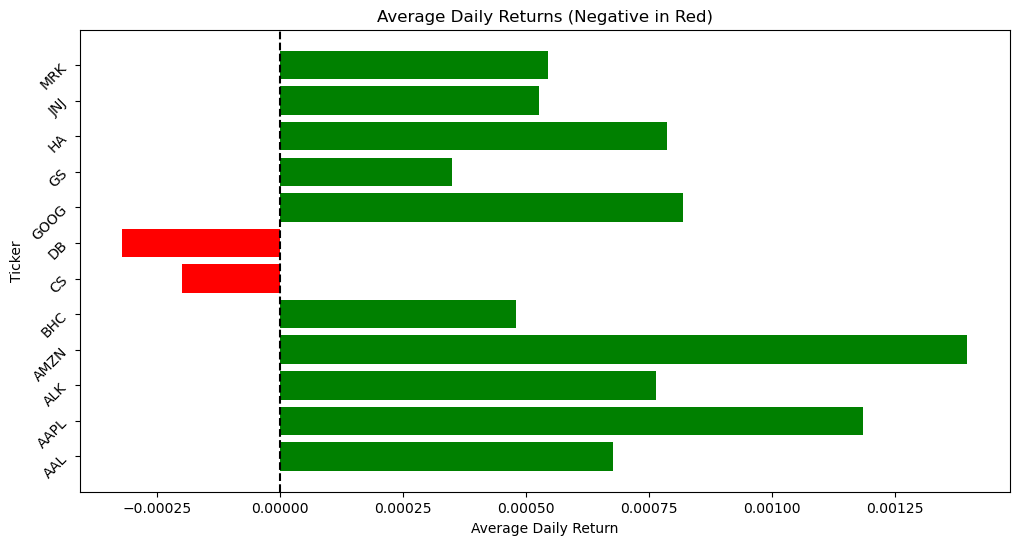

In [26]:
plot_data = returns_summary[returns_summary["Ticker"] != "S&P500"]

# Adding colours for better viz
plot_data["Color"] = plot_data["Average_Return"].apply(lambda x: "red" if x < 0 else "green")

# Plotting bar-h chart
plt.figure(figsize=(12,6))
plt.barh(plot_data["Ticker"], plot_data["Average_Return"], color=plot_data["Color"])
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Average Daily Return")
plt.ylabel("Ticker")
plt.title("Average Daily Returns (Negative in Red)")
plt.yticks(rotation=45)
plt.show()

- Deutsche Bank and Credit Suisse have negative average returns over the time period. Not a good choice for our portfolio.
- Amazon and Apple have given the highest average returns.

In [28]:
# Computing Stock Price Dispersion from mean

def plot_dispersion_by_industry(df, plot_type="kde", bins=30):

    industries = df["Industry"].unique()
    
    for industry in industries:
        subset_ind = df[df["Industry"] == industry].copy()
        plt.figure(figsize=(10,6))
        
        tickers = subset_ind["Ticker"].unique()
        for ticker in tickers:
            stock_data = subset_ind[subset_ind["Ticker"] == ticker].copy()
            mean_price = stock_data["Adj Close"].mean()
            stock_data["Relative_Deviation"] = (stock_data["Adj Close"] - mean_price) / mean_price * 100
            
            if plot_type == "hist":
                plt.hist(stock_data["Relative_Deviation"], bins=bins, alpha=0.5, label=ticker)
            elif plot_type == "kde":
                sns.kdeplot(stock_data["Relative_Deviation"], label=ticker, fill=True, alpha=0.5)
        
        plt.axvline(0, color="red", linestyle="--", label="Mean")
        plt.xlabel("Relative Deviation from Mean (%)")
        plt.ylabel("Density")
        plt.title(f"Price Dispersion from Mean - Industry: {industry}")
        plt.legend()
        plt.show()

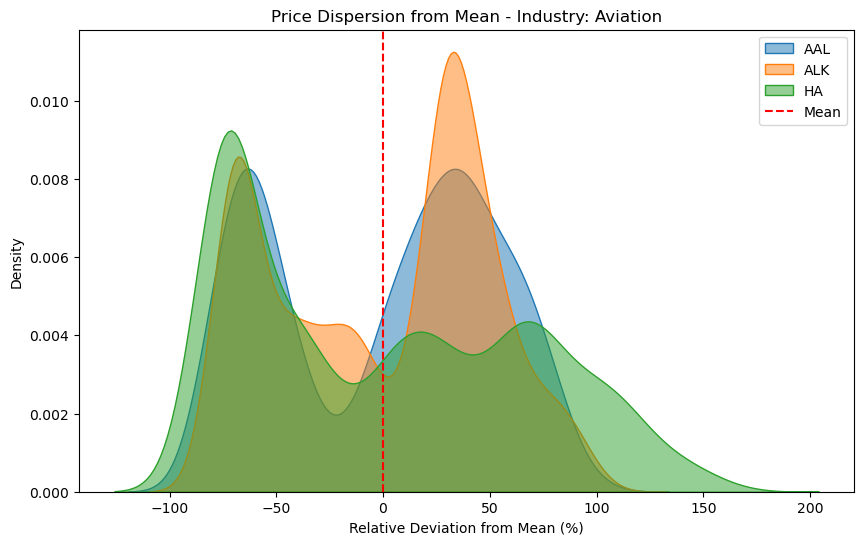

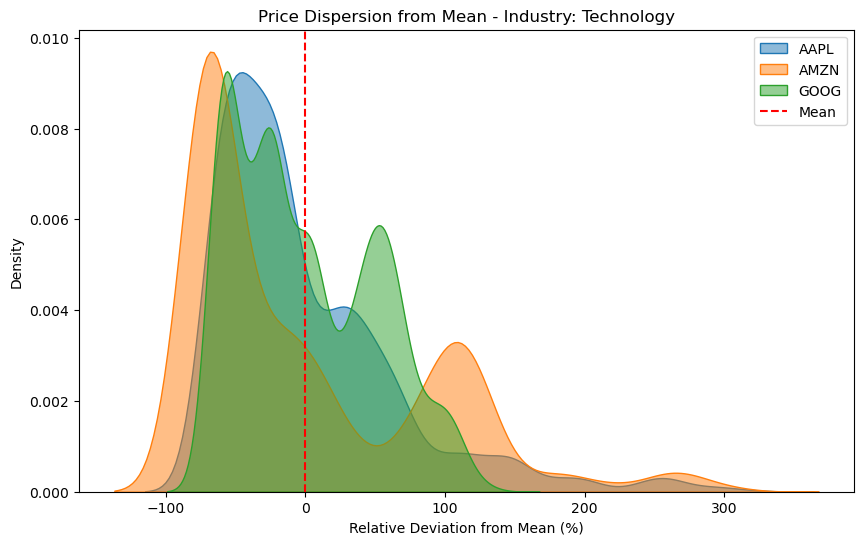

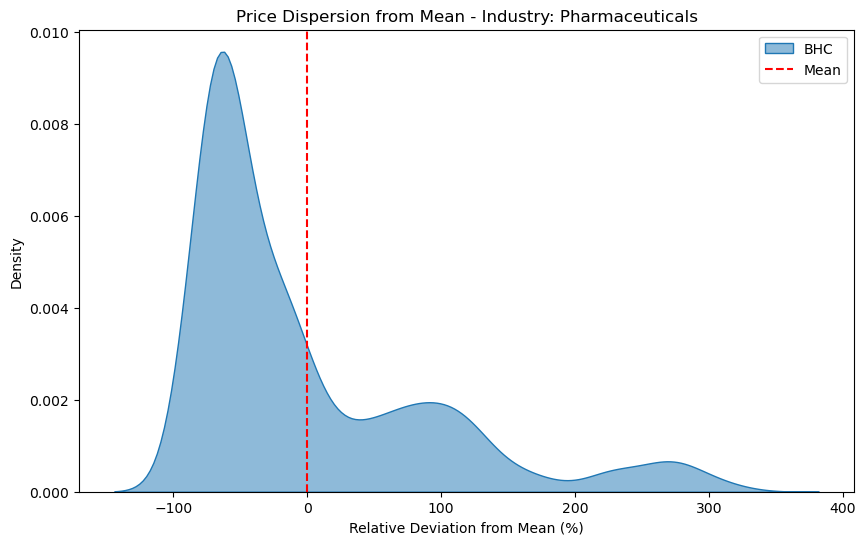

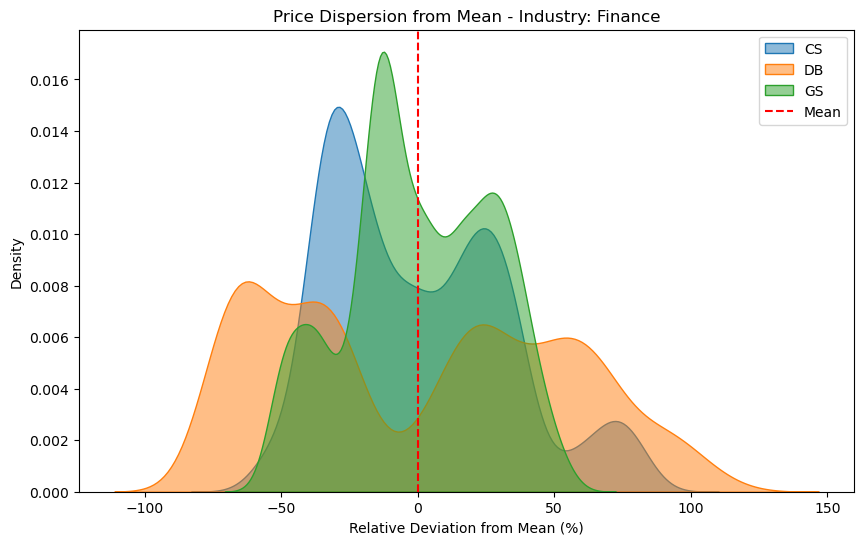

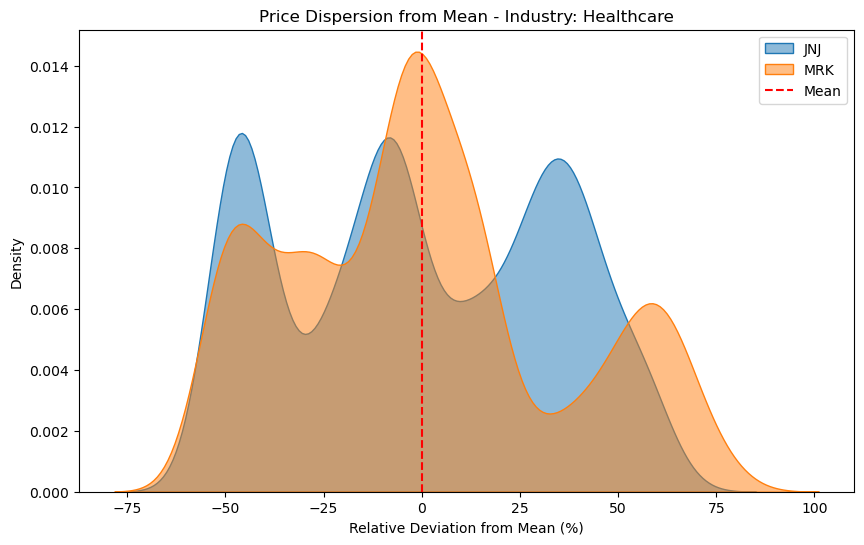

In [29]:
plot_dispersion_by_industry(stock_analysis_dataset_raw, plot_type = "kde")

#### Inference

Aviation

- AAL → Volatile with slight upward bias but vulnerable to big drops.
- ALK → Most stable aviation stock with modest positive returns.
- HA → Highly risky with extreme up-and-down swings.
- Aviation is highly volatile overall, but ALK stands out as the most stable choice.

Technology

- AAPL → Stable and moderately volatile, often just below the mean.
- AMZN → Very volatile but offers strong upside potential.
- GOOG → Balanced risk but less consistent than peers.
- Technology shows strong upside with volatility, and AAPL is the most balanced pick.

Pharmaceuticals

- BHC → Extremely volatile and speculative with huge swings.
- Pharmaceuticals are extremely speculative, and BHC is not a safe bet here.

Finance

- CS → Stable but tends to underperform the mean price.
- DB → Volatile with more time spent below the mean.
- GS → Strongest performer in finance, with balanced dispersion.
- Finance shows mixed dispersion, with GS emerging as the most reliable performer.

Healthcare

- JNJ → Moderately volatile with a slight positive tilt.
- MRK → Very stable and predictable, lowest volatility.
- Healthcare is the most stable sector, with MRK offering the safest investment profile.

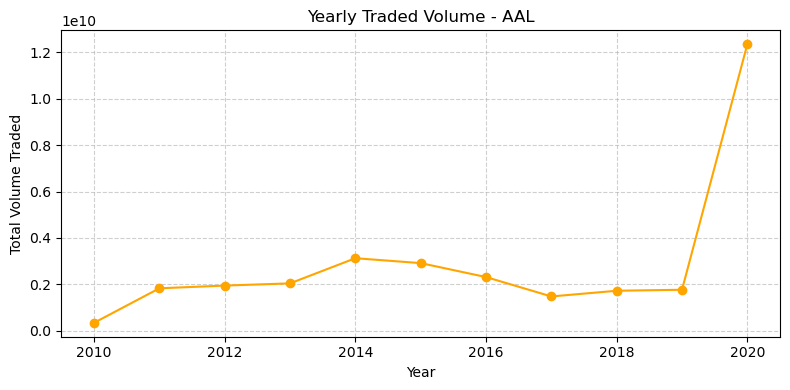

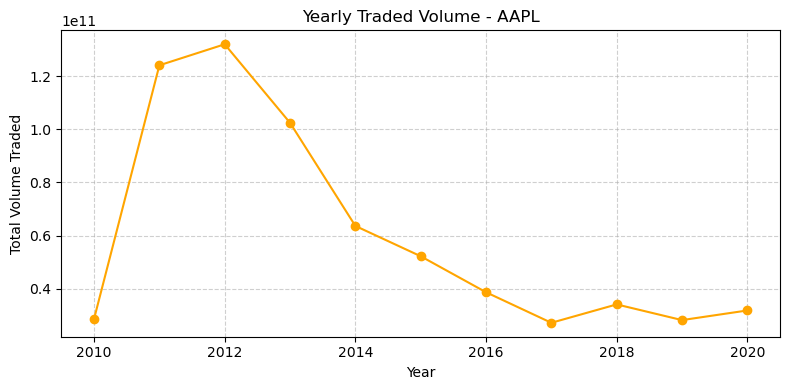

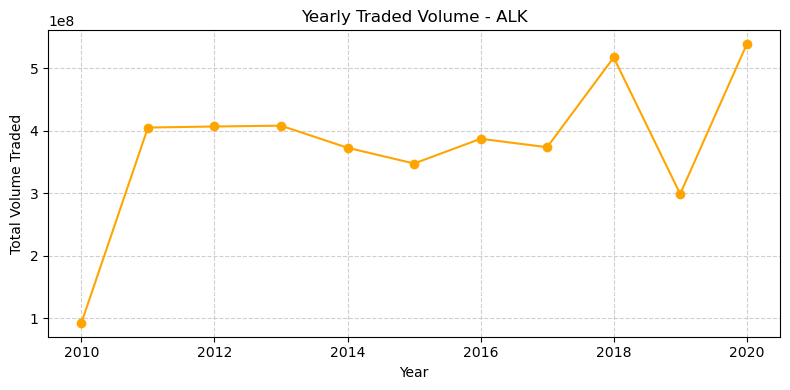

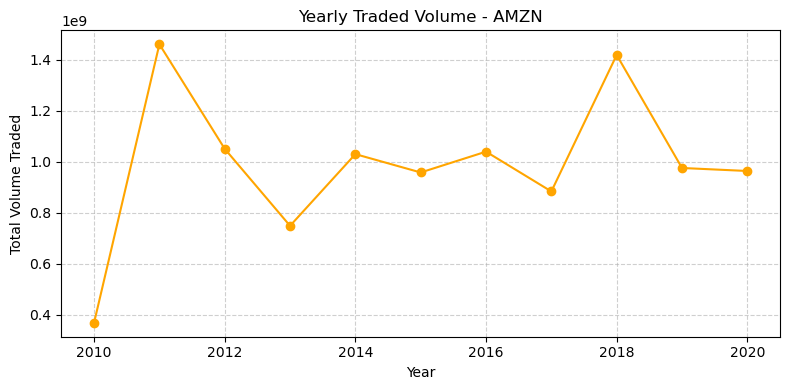

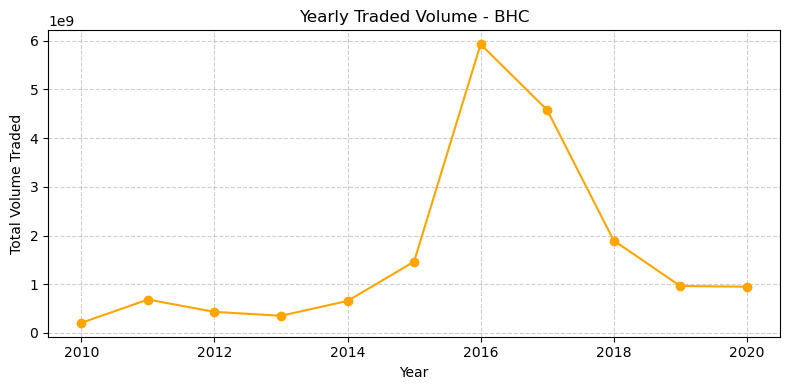

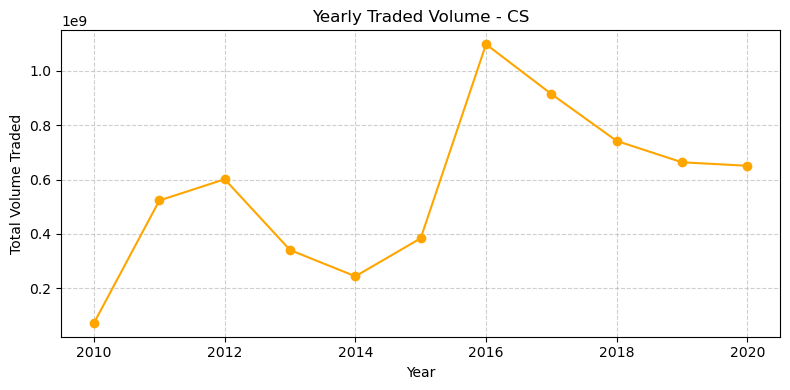

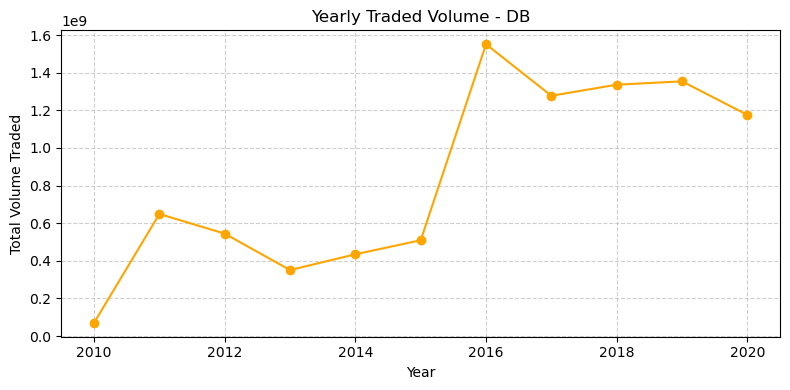

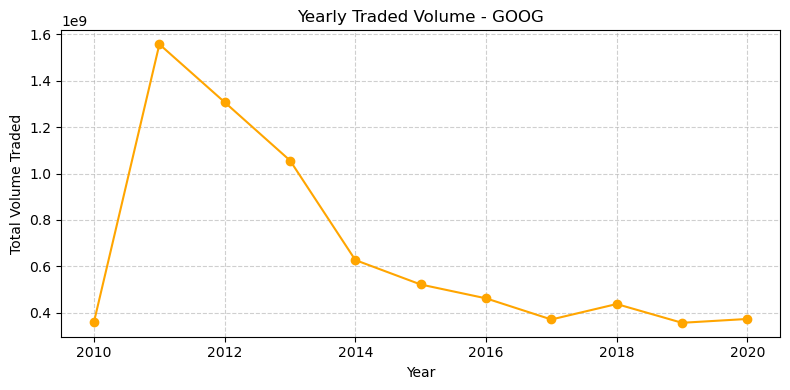

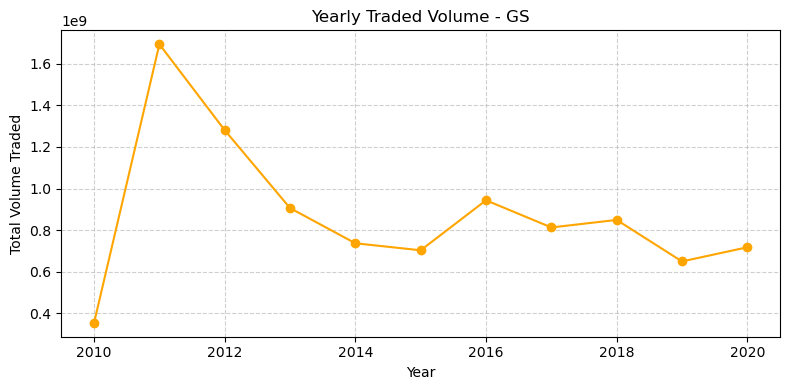

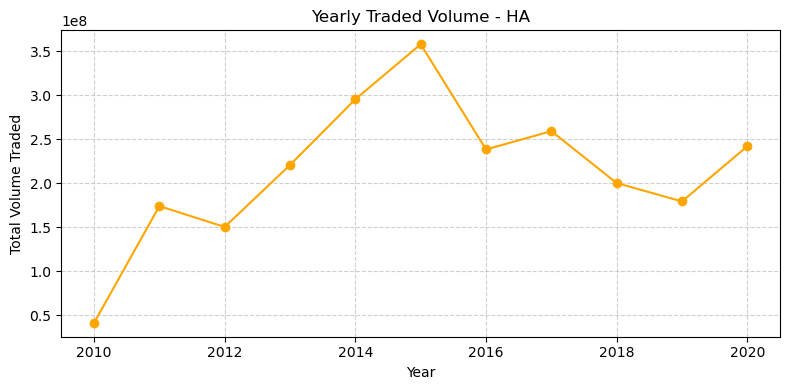

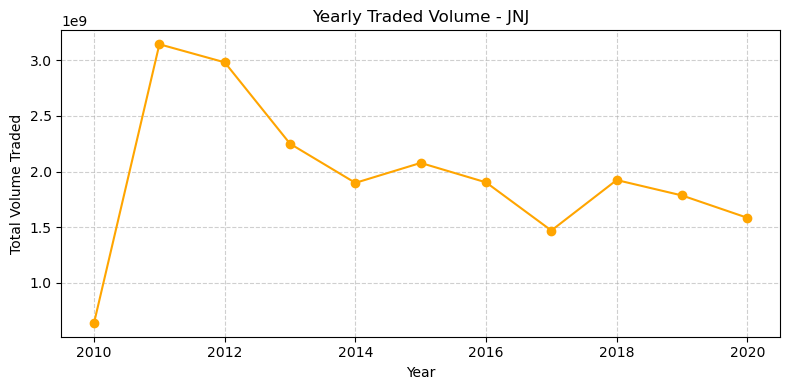

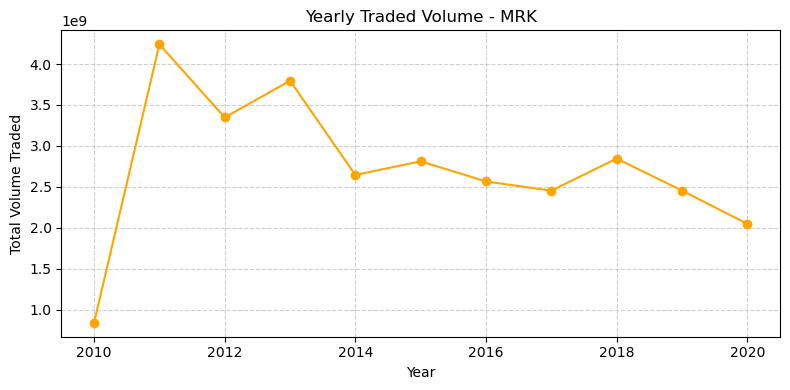

In [31]:
# Computing yearly volume traded trends across the 10 years.

stock_analysis_dataset_raw["Year"] = pd.to_datetime(stock_analysis_dataset_raw["Date"]).dt.year
yearly_volume = stock_analysis_dataset_raw.groupby(["Year", "Ticker"])["Volume"].sum().reset_index()

tickers = yearly_volume["Ticker"].unique()

for ticker in tickers:
    stock_data = yearly_volume[yearly_volume["Ticker"] == ticker]
    
    plt.figure(figsize=(8, 4))
    plt.plot(stock_data["Year"], stock_data["Volume"], marker="o", color="orange")
    
    plt.title(f"Yearly Traded Volume - {ticker}")
    plt.xlabel("Year")
    plt.ylabel("Total Volume Traded")
    plt.grid(linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### Inference

- Build a stable base with Tech + Healthcare (steady liquidity, long-term growth focus).
- Add Financial + Aviation stocks selectively as “event-driven” tactical allocations to capture crisis/opportunity spikes.

In [33]:
# Computing maximum and minimum values and a spread across these values to compare across industries and price ranges.

price_stats = stock_analysis_dataset_raw.groupby(["Ticker", stock_analysis_dataset_raw["Date"].dt.year.rename("Year")])["Adj Close"].agg(
    Min_Price="min", Max_Price="max").reset_index()

# Merging industry info into price_stats
price_stats = price_stats.merge(stock_analysis_dataset_raw[["Ticker", "Industry"]].drop_duplicates(), on="Ticker", how="left")
price_stats = price_stats.sort_values(by=["Industry", "Ticker"]).reset_index(drop=True)

# Computing relative spread of max and min values and a percentage of min (normalised)

price_stats["Relative Spread"] = ((price_stats["Max_Price"] - price_stats["Min_Price"])/price_stats["Min_Price"] * 100).round(2)

# Min max ratio

price_stats["Min_max_Ratio"] = (price_stats["Max_Price"]/price_stats["Min_Price"]).round(2)

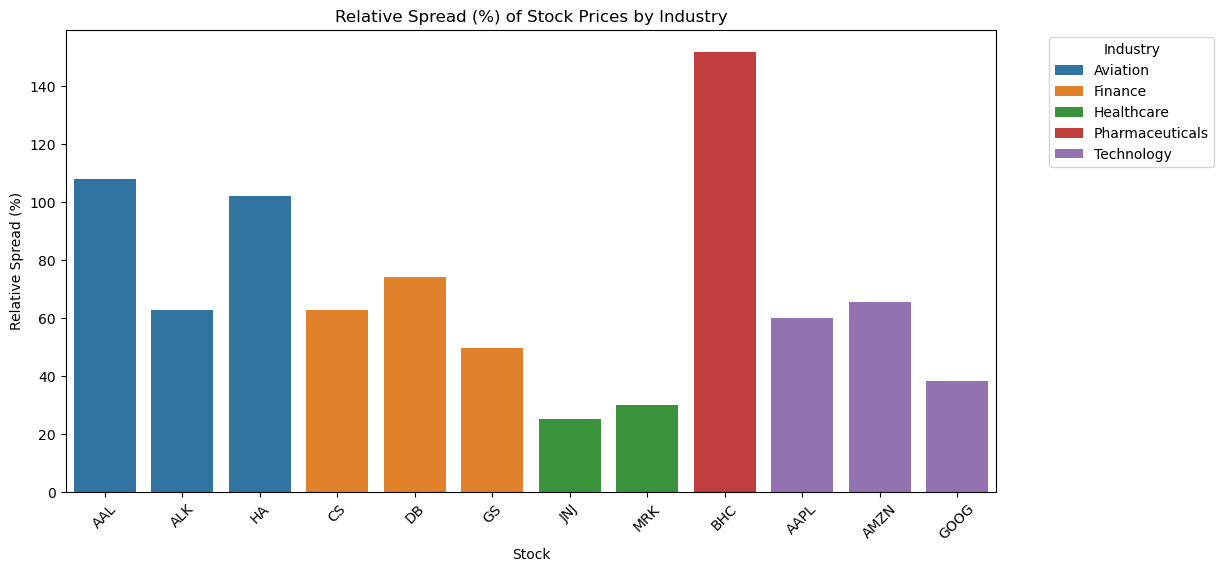

In [34]:
# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=price_stats, x="Ticker", y="Relative Spread", hue="Industry", dodge=False, errorbar=None)
plt.title("Relative Spread (%) of Stock Prices by Industry")
plt.ylabel("Relative Spread (%)")
plt.xlabel("Stock")
plt.xticks(rotation=45)
plt.legend(title="Industry", bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

### Inference

- `BHC (Pharmaceuticals)` has the highest relative spread at around 150%, making it the most volatile stock in the dataset. This suggests it carries the highest individual risk.

- `JNJ (Healthcare)` has the lowest relative spread at just under 30%, making it the least volatile and seemingly the safest stock in the dataset.

- The Aviation industry, represented by `AAL and HA`, has stocks with relative spreads over 100%, indicating significant volatility. ALK has a lower spread of around 60%.

- In the Finance industry, the spreads for `CS, DB, and GS` range from approximately 50% to 75%, showing a moderate but consistent level of volatility.

- The Technology industry stocks `(AAPL, AMZN, GOOG)` have spreads ranging from around 40% to 65%, placing them in the moderate volatility category.

In [36]:
# The maximum and minimum prices during the analysis period 2010 to 2020

max_prices = price_stats.groupby("Ticker")["Max_Price"].max().sort_values(ascending=False)
print("\nMaximum price for each stock\n\n", max_prices)

min_prices = price_stats.groupby("Ticker")["Min_Price"].min().sort_values(ascending=True)
print("\nMinimum price for each stock\n\n", min_prices)


Maximum price for each stock

 Ticker
AMZN    3531.450
GOOG    1728.280
BHC      262.520
GS       260.139
JNJ      153.830
AAPL     134.180
ALK       94.471
MRK       89.912
HA        58.100
AAL       56.989
DB        53.558
CS        33.230
Name: Max_Price, dtype: float64

Minimum price for each stock

 Ticker
HA        3.642
AAL       3.771
DB        5.480
CS        6.553
BHC       8.510
AAPL      8.599
ALK      10.243
MRK      21.931
JNJ      43.686
GS       76.414
AMZN    153.030
GOOG    236.553
Name: Min_Price, dtype: float64


In [37]:
# Average Number of trading days per year for each stock in our dataset

trading_days_per_year = stock_analysis_dataset_raw.groupby(["Ticker", "Year"])["Date"].nunique().reset_index(name="Trading_Days")
average_trading_days = trading_days_per_year["Trading_Days"].mean().round(0)
average_trading_days

229.0

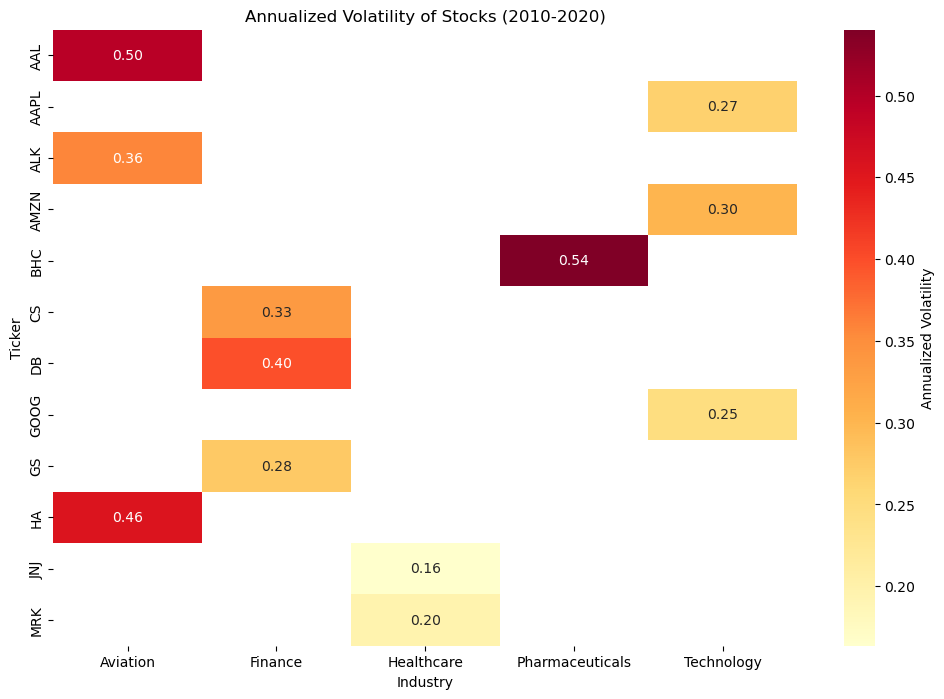

In [38]:
# Risk and volatility analysis of our stocks

# We will use the standard deviation of the daily return as a measure of volatility risk and visualise on a heat map

volatility = stock_analysis_dataset_raw.groupby("Ticker")["Daily_Return"].std().rename("Daily_Volatility")

# Annualised volatility will give us a better idea of riskiness for long-term investing
volatility_annualized = volatility * np.sqrt(average_trading_days)
volatility_annualized = volatility_annualized.rename("Annualized_Volatility")

vol_df = pd.concat([volatility, volatility_annualized], axis=1).reset_index()
vol_df = vol_df.merge(stock_analysis_dataset_raw[["Ticker", "Industry"]].drop_duplicates(), on="Ticker", how="left")

heatmap_data = vol_df.pivot(index="Ticker", columns="Industry", values="Annualized_Volatility")

# plotting the heatmap
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Annualized Volatility'})
plt.title("Annualized Volatility of Stocks (2010-2020)")
plt.ylabel("Ticker")
plt.xlabel("Industry")
plt.show()


### Inference

High volatility stocks:

- BHC (Pharmaceuticals) ~0.54AAL (Aviation) ~0.50
- HA (Aviation) ~0.46
- These stocks experienced large fluctuations in price, so they are riskier.

Moderate volatility stocks:

- DB (Finance) ~0.40
- ALK (Aviation) ~0.36
- AMZN (Technology) ~0.30
- These have some risk but less than the extremes.

Low volatility stocks:

- JNJ (Healthcare) ~0.16
- MRK (Healthcare) ~0.20
- Stable stocks with small day-to-day changes, good for conservative investments.

Industry patterns:

- Aviation stocks tend to be more volatile than Healthcare or Technology here.
- Healthcare stocks appear least volatile, suggesting stability.
- Technology has moderate volatility

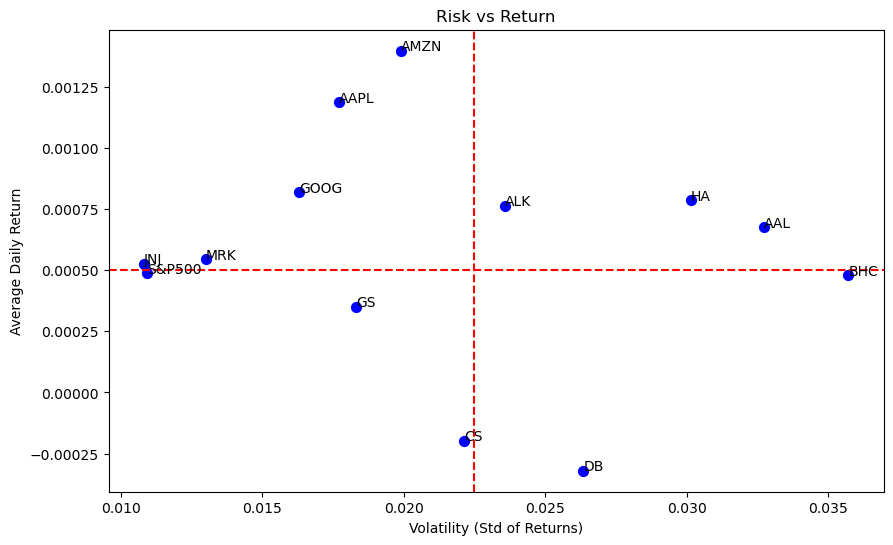

In [40]:
# Scatter plot for visualising risk vs return by volatility

# Taking 0.022 as max risk and 0.00050 as expected return for max risk

plt.figure(figsize=(10,6))
plt.scatter(returns_summary["Volatility"], returns_summary["Average_Return"], color="blue", s=50)
plt.axhline(0.00050, color="red", linestyle="--")
plt.axvline(0.0225, color="red", linestyle="--")
plt.xlabel("Volatility (Std of Returns)")
plt.ylabel("Average Daily Return")
plt.title("Risk vs Return")
for i, txt in enumerate(returns_summary["Ticker"]):
    plt.annotate(txt, (returns_summary["Volatility"][i], returns_summary["Average_Return"][i]))
plt.show()


### Inference

- AMZN, AAPL, GOOG → Top-left → Low risk, high return → Strong candidates for stable growth
- HA, AAL, BHC → Top-right → High risk, high return → Aggressive growth opportunities
- JNJ, MRK → Bottom-left → Low risk, low return → Stable but low growth
- DB, CS → Bottom-right → High risk, low return → Stocks to avoid

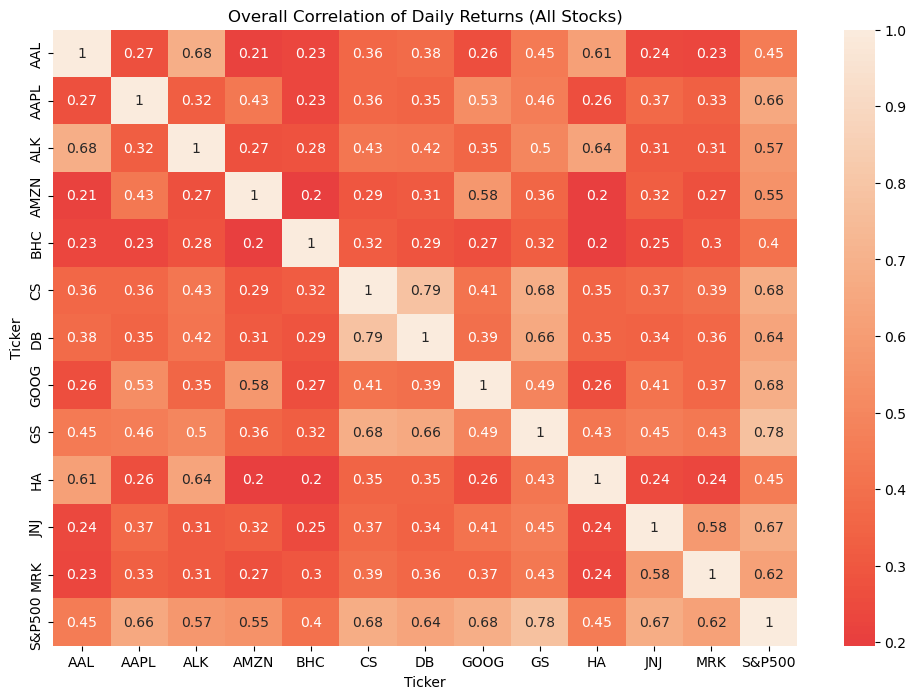

In [42]:
# Correlation Analysis

overall_correlation = returns.corr()
plt.figure(figsize=(12,8))
sns.heatmap(overall_correlation, cmap="rocket", center=0, annot=True)
plt.title("Overall Correlation of Daily Returns (All Stocks)")
plt.show()

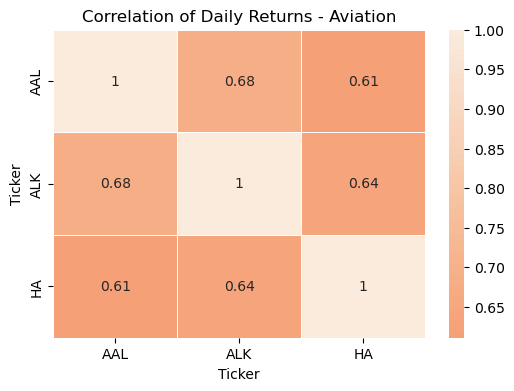

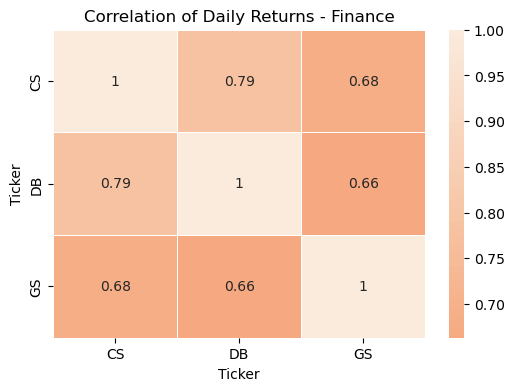

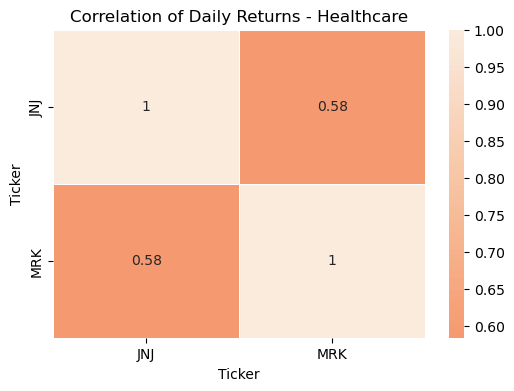

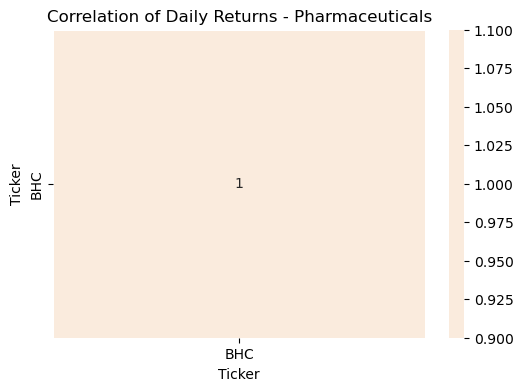

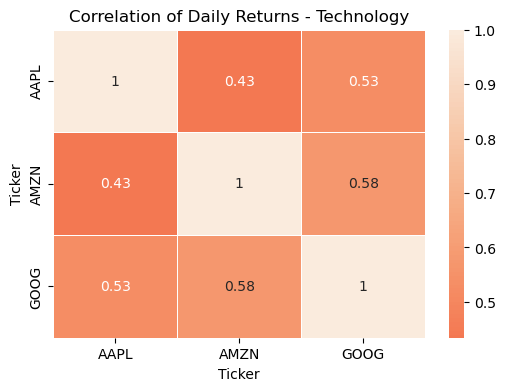

In [43]:
# Creating Sector-wise datasets

# {Industry: [list of tickers]}
industry_dict = (stock_analysis_dataset_raw.groupby("Industry")["Ticker"].unique().apply(list).to_dict())

industry_returns = {}

for industry, tickers in industry_dict.items():
    industry_returns[industry] = returns[tickers]

for industry, df in industry_returns.items():
    plt.figure(figsize=(6,4))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap="rocket", center=0, linewidths=0.5)
    plt.title(f"Correlation of Daily Returns - {industry}")
    plt.show()

### Inference
Key pattern: Most cross-sector pairs show low–moderate correlations (0.2–0.4) → strong diversification potential.

Notably higher correlations:

- Aviation (AAL–ALK 0.68, AAL–HA 0.61, ALK–HA 0.64) → move together. These three stocks behave like one asset—high exposure to the same economic shocks (fuel, travel demand). For a conservative portfolio, we can hold at most one airline  for sector exposure, and only in a small weight.
  
- Finance (CS–DB 0.79, CS–GS 0.68, DB–GS 0.66) → highly co-moving. Global banking stocks are strongly linked to interest-rate and credit cycles. Also, DB and CS have negative average returns over the 10 years. We will be avoiding these stocks.

- Tech (GOOG–AMZN 0.58, AAPL–GOOG 0.53) → moderate. Moderate correlation—less than airlines/banks—so holding two of these still offers some diversification.
  
- Healthcare (JNJ–MRK 0.58) → moderate. 

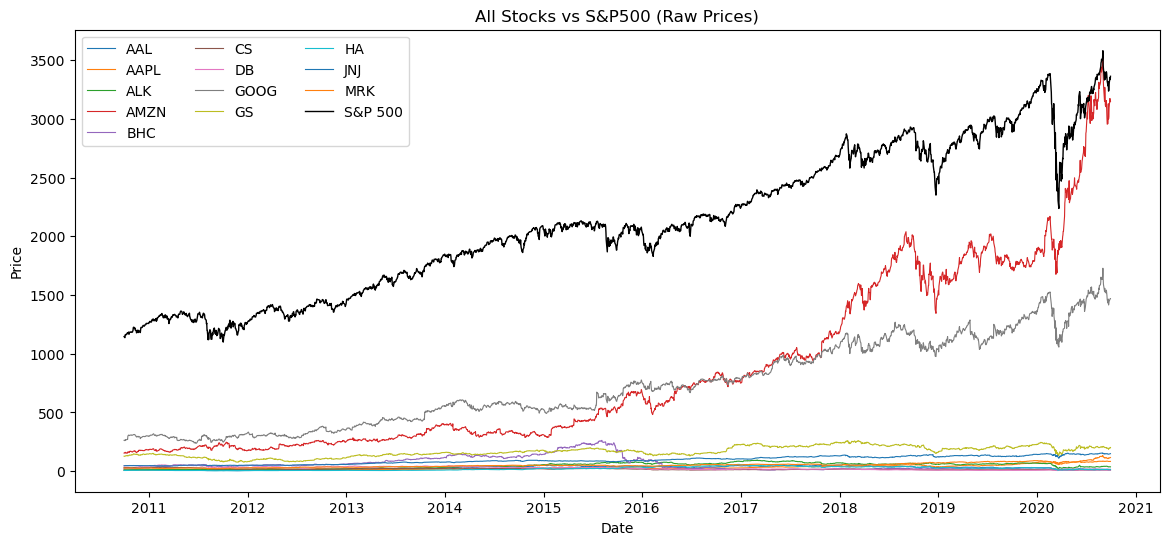

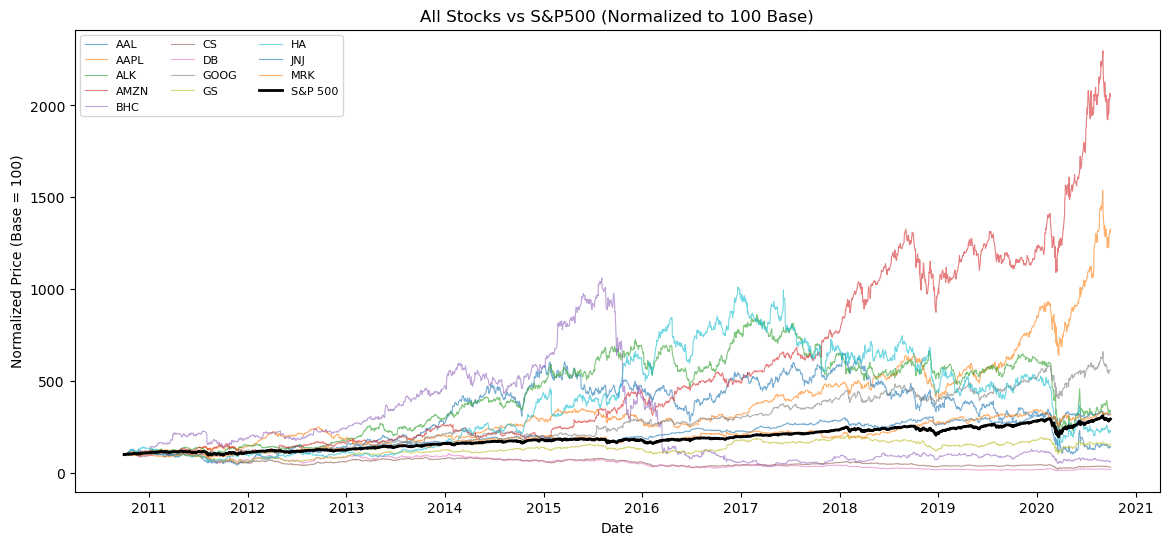

In [45]:
# Comparison of performance of all stocks vs S&P 500 with and without normalisation
price_data = stock_analysis_dataset_raw.pivot(index="Date", columns="Ticker", values="Adj Close")
price_data["SP500"] = stock_analysis_dataset_raw.drop_duplicates("Date").set_index("Date")["SP500_Adj_Close"]

# Normalized prices
normalized_prices = price_data / price_data.iloc[0] * 100

# Plotting raw prices to compare with S&P 500
plt.figure(figsize=(14,6))
for ticker in price_data.columns:
    if ticker != "SP500":
        plt.plot(price_data.index, price_data[ticker], linewidth=0.8, label=ticker)
plt.plot(price_data.index, price_data["SP500"], color="black", linewidth=1, label="S&P 500")

plt.title("All Stocks vs S&P500 (Raw Prices)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3, fontsize=10) 
plt.show()


# Plotting normalised prices with base as 100 to compare relative performance — e.g., “which stock/industry grew more since 2010.”

plt.figure(figsize=(14,6))
for ticker in normalized_prices.columns:
    if ticker != "SP500":
        plt.plot(normalized_prices.index, normalized_prices[ticker], alpha=0.6, linewidth=0.8, label=ticker)
plt.plot(normalized_prices.index, normalized_prices["SP500"], color="black", linewidth=2, label="S&P 500")

plt.title("All Stocks vs S&P500 (Normalized to 100 Base)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend(ncol=3, fontsize=8)   # Adjust legend size & columns
plt.show()


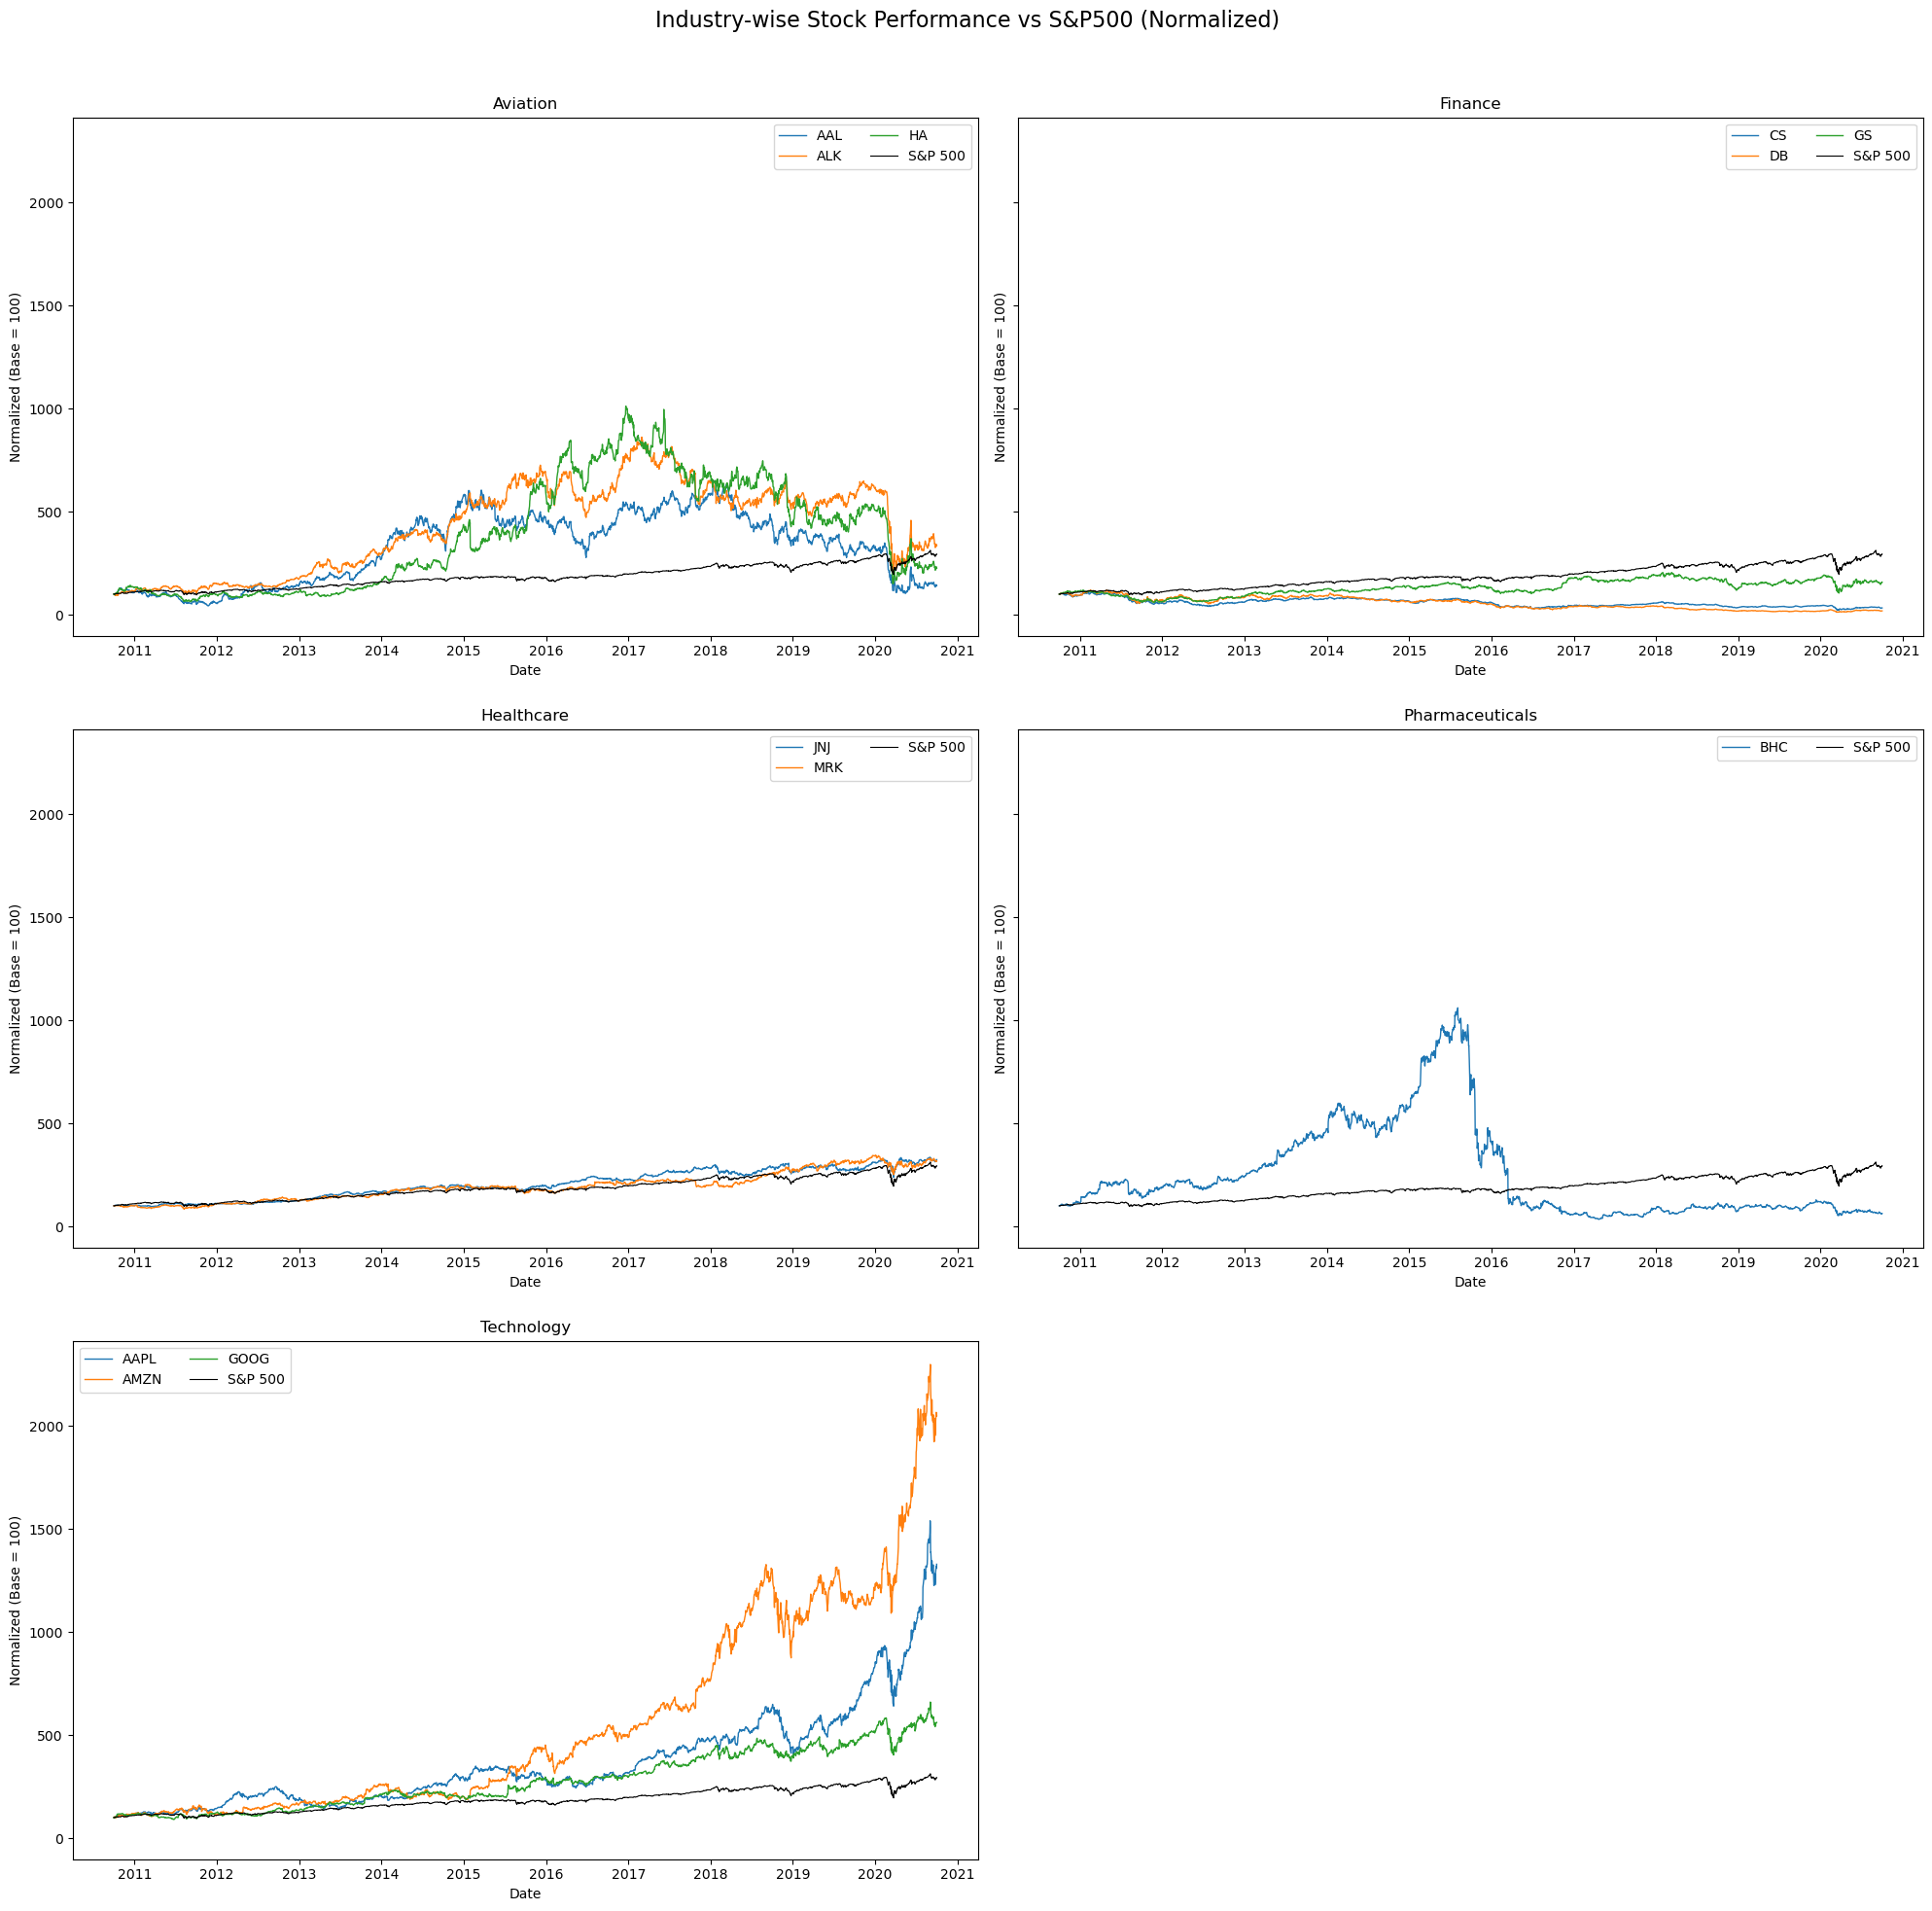

In [46]:
industries = list(industry_dict.keys())

fig, axes = plt.subplots(3, 2, figsize=(20,20), sharex=False, sharey=True)
axes = axes.flatten()

for i, industry in enumerate(industries):
    ax = axes[i]
    tickers = industry_dict[industry]
    
    # Plot each stock in this industry
    for ticker in tickers:
        if ticker in normalized_prices.columns:
            ax.plot(normalized_prices.index, normalized_prices[ticker], linewidth=1, label=ticker)
    
    # Add S&P 500
    ax.plot(normalized_prices.index, normalized_prices["SP500"], color="black", linewidth=0.8, label="S&P 500")
    
    ax.set_title(f"\n{industry}", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized (Base = 100)")
    ax.legend(fontsize=10, ncol=2)

# Remove unused subplot spaces if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Industry-wise Stock Performance vs S&P500 (Normalized)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Inference

Technology (AMZN, AAPL, GOOG) shows the largest absolute and normalised outperformance but also the largest volatility and drawdowns. AMZN massively outperformed (huge upside) — but with sharp swings.

Aviation stocks (AAL, ALK, HA) are highly cyclical and show big booms and deep crashes (especially around 2020)—large drawdowns — not reliable for capital preservation.

Banks/Finance (CS, DB, GS) are mixed: CS and DB appear weak or flat, falling relative to the S&P (due to structural issues), while GS looks more resilient but remains cyclical.

Healthcare (JNJ, MRK) are the flattest, smoothest growth line — low volatility and decent steady appreciation (classic defensive sector).

Pharmaceutical (BHC) shows an extreme idiosyncratic spike and crash (huge company-specific event) — high idiosyncratic risk.

### Data Exploration Summary

We explored returns, volatility, volume trends, spreads, correlations, and performance vs S&P 500 across sectors.

#### Key Findings:

Returns: Amazon (AMZN) and Apple (AAPL) are the strongest performers; Deutsche Bank (DB) and Credit Suisse (CS) show negative returns → to be avoided.

#### Volatility:

High → BHC, AAL, HA (risky, speculative).

Moderate → AMZN, ALK, GS.

Low → JNJ, MRK (defensive, stable).

#### Industry patterns:

Aviation → very volatile, with ALK relatively stable.

Technology → strong upside, moderate volatility; best growth potential.

Healthcare → least volatile; strong defensive sector.

Finance → DB, CS weak; GS stronger but cyclical.

Pharma (BHC) → extreme volatility; avoid.

#### Risk vs Return:

Best quadrant: AMZN, AAPL, GOOG → strong risk-adjusted returns.

Defensive: JNJ, MRK → low risk, low return.

Avoid: DB, CS (high risk, low return).

#### Correlation Analysis:

Airlines and banks are highly correlated → one stock per sector at most.

Tech and Healthcare have moderate correlations → allow diversification.

#### Relative to S&P 500:

Tech stocks massively outperformed with volatility.

Healthcare steady and defensive.

Aviation and Finance underperformed or unstable.

BHC extreme event-driven swings.

### Strongest Picks Based on Analysis

#### Core Growth (High Return, Manageable Risk):

Amazon (AMZN)

Apple (AAPL)

Google (GOOG)

#### Defensive Stability (Low Risk, Steady Growth):

Johnson & Johnson (JNJ)

Merck (MRK)

#### Selective Opportunistic Play (Event-driven):

Alaska Airlines (ALK)

Goldman Sachs (GS)

#### Avoid: DB, CS (weak performance), BHC (too volatile), AAL/HA (highly risky cyclicals).

-----------------

## <font color = Dark> _3. Stock Analysis and Portfolio Management_

The following steps outline the process:

1. **Defining the investor profile**
2. **Calculating the financial metrics using the CAPM approach**
3. **Assigning weights**
4. **Weighted scoring of stocks for final selection**

### Investor profile

- `Time Horizon:` 4–6 years (long-term).
- `Goal:` Steady wealth creation, outperform S&P 500 benchmark.
- `Risk Appetite:` Moderate (not hyper-speculative).
- `Constraints:` Avoid highly correlated, extremely volatile stocks

#### Portfolio analysis based on CAPM, Beta, Jenson's Alpha and Sharpe Ratio

- CAPM tells us the expected return of a stock given its risk (beta) compared to the market.
- Beta measures how much the stock moves compared to the market.
    - If β = 1 → moves with the market.
    - If β > 1 → more volatile than market (riskier, but higher potential return).
    - If β < 1 → defensive stock, less sensitive to market swings.
- Jensen’s Alpha compares the actual return vs the CAPM expected return.
- Sharpe Ratio measures return per unit of risk (volatility).
- Higher is better:
    - < 0 → losing money after adjusting for risk.
    - 0–0.5 → poor, not worth the risk.
    - 0.5–1 → decent, but not amazing.
    - 1 → excellent, strong risk-adjusted return.

In [55]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Market column
market_col = "S&P500"
X = returns[[market_col]].values

# Betas
betas = {}
for col in returns.columns:
    if col == market_col:
        continue
    y = returns[col].values.reshape(-1, 1)
    lr = LinearRegression().fit(X, y)
    betas[col] = lr.coef_[0][0]

beta = pd.Series(betas, name="Beta")

# Risk-free rate
rf_annual = 0.0075
rf_daily = (1 + rf_annual)**(1/252) - 1

# Market expected return
erm_daily = returns[market_col].mean()

# Actual daily returns
actual_daily = returns.drop(columns=[market_col]).mean()

# Jensen’s Alpha
jensen_alpha_daily = (actual_daily - rf_daily) - beta * (erm_daily - rf_daily)
jensen_alpha_annual = (1 + jensen_alpha_daily)**252 - 1

# CAPM Expected Return
capm_expected_daily  = rf_daily + beta * (erm_daily - rf_daily)
capm_expected_annual = (1 + capm_expected_daily) ** 252 - 1

# Actual Annual Return
actual_annual = (1 + actual_daily) ** 252 - 1

# Volatility & Sharpe Ratio
vol_daily = returns.drop(columns=[market_col]).std()
vol_annual = vol_daily * np.sqrt(252)

sharpe_ratio = (actual_annual - rf_annual) / vol_annual


capm_df = pd.concat([beta, capm_expected_annual.rename("CAPM Exp Annual"), actual_annual.rename("Actual Annual"), 
                     jensen_alpha_annual.rename("Jensen Alpha Annual"), vol_annual.rename("Volatility Annual"),
                     sharpe_ratio.rename("Sharpe Ratio")], axis=1).sort_index()

capm_df.round(3)

,Beta,CAPM Exp Annual,Actual Annual,Jensen Alpha Annual,Volatility Annual,Sharpe Ratio
AAL,1.353,0.178,0.186,0.007,0.519,0.344
AAPL,1.063,0.139,0.348,0.184,0.281,1.212
ALK,1.232,0.162,0.212,0.044,0.374,0.548
AMZN,0.999,0.131,0.422,0.258,0.316,1.312
BHC,1.316,0.173,0.129,-0.038,0.567,0.214
CS,1.373,0.181,-0.049,-0.194,0.351,-0.160
DB,1.536,0.203,-0.078,-0.233,0.418,-0.203
GOOG,1.013,0.133,0.230,0.086,0.259,0.859
GS,1.301,0.171,0.092,-0.067,0.291,0.292
HA,1.234,0.162,0.219,0.050,0.479,0.443


In [56]:
# We will use a weighted scoring approach to rank the stocks based on the above financial metrics
# Based on our investor profile, the main focus should be: 
# Maximising returns: Actual Annual Return, Jensen Alpha
# Reward per unit risk: Sharpe Ratio
# Control risk exposure moderately: Beta and Volatility

In [57]:
#  Metric	      Importance for long-term	       Reason                           Weight Score
#  Jensen Alpha	  High	                           Outperformance beyond market     3
#  Actual Return  High	                           Realised growth over time        3
#  Sharpe Ratio   Medium	                       Risk-adjusted performance        2
#  Beta	          Low	                           Moderate market sensitivity      1
#  Volatility	  Low	                           Prefers lower variability        1

In [58]:
# Define importance scores (1=low, 2=medium, 3=high)
importance = {'Jensen Alpha Annual': 3, 'Actual Annual': 3, 'Sharpe Ratio': 2, 'Beta': 1, 'Volatility Annual': 1} 

# Sum of importance
total = sum(importance.values())

# Convert to weights
weights = {k: v/total for k, v in importance.items()}
weights

{'Jensen Alpha Annual': 0.3,
 'Actual Annual': 0.3,
 'Sharpe Ratio': 0.2,
 'Beta': 0.1,
 'Volatility Annual': 0.1}

In [59]:
# Normalising the metrics where Higher is better
capm_weighted_norm_score = capm_df.copy()

capm_weighted_norm_score['Jensen_norm'] = (capm_weighted_norm_score['Jensen Alpha Annual'] - capm_weighted_norm_score['Jensen Alpha Annual'].min()) / (capm_weighted_norm_score['Jensen Alpha Annual'].max() - capm_weighted_norm_score['Jensen Alpha Annual'].min())
capm_weighted_norm_score['Actual_norm'] = (capm_weighted_norm_score['Actual Annual'] - capm_weighted_norm_score['Actual Annual'].min()) / (capm_weighted_norm_score['Actual Annual'].max() - capm_weighted_norm_score['Actual Annual'].min())
capm_weighted_norm_score['Sharpe_norm'] = (capm_weighted_norm_score['Sharpe Ratio'] - capm_weighted_norm_score['Sharpe Ratio'].min()) / (capm_weighted_norm_score['Sharpe Ratio'].max() - capm_weighted_norm_score['Sharpe Ratio'].min())

In [60]:
# Normalising the metrics where Lower is better

capm_weighted_norm_score['Beta_norm'] = (capm_weighted_norm_score['Beta'].max() - capm_weighted_norm_score['Beta']) / (capm_weighted_norm_score['Beta'].max() - capm_weighted_norm_score['Beta'].min())
capm_weighted_norm_score['Volatility_norm'] = (capm_weighted_norm_score['Volatility Annual'].max() - capm_weighted_norm_score['Volatility Annual']) / (capm_weighted_norm_score['Volatility Annual'].max() - capm_weighted_norm_score['Volatility Annual'].min())

In [61]:
# Computing the weighted score for the stocks

capm_df['Weighted Score'] = (capm_weighted_norm_score['Jensen_norm']*weights['Jensen Alpha Annual'] + 
                             capm_weighted_norm_score['Actual_norm']*weights['Actual Annual'] +
                             capm_weighted_norm_score['Sharpe_norm']*weights['Sharpe Ratio'] +
                             capm_weighted_norm_score['Beta_norm']*weights['Beta'] +
                             capm_weighted_norm_score['Volatility_norm']*weights['Volatility Annual'])

capm_df = capm_df.sort_values('Weighted Score', ascending=False)

# Converting scores to base 100

capm_df['Weighted Score'] = capm_df['Weighted Score'] * 100
capm_df = capm_df.round(2)

In [62]:
capm_df

,Beta,CAPM Exp Annual,Actual Annual,Jensen Alpha Annual,Volatility Annual,Sharpe Ratio,Weighted Score
AMZN,1.00,0.13,0.42,0.26,0.32,1.31,92.51
AAPL,1.06,0.14,0.35,0.18,0.28,1.21,82.36
GOOG,1.01,0.13,0.23,0.09,0.26,0.86,65.74
JNJ,0.66,0.09,0.14,0.05,0.17,0.78,63.46
MRK,0.74,0.10,0.15,0.05,0.21,0.68,60.41
ALK,1.23,0.16,0.21,0.04,0.37,0.55,52.61
HA,1.23,0.16,0.22,0.05,0.48,0.44,49.34
AAL,1.35,0.18,0.19,0.01,0.52,0.34,41.01
GS,1.30,0.17,0.09,-0.07,0.29,0.29,36.58
BHC,1.32,0.17,0.13,-0.04,0.57,0.21,32.34


In [63]:
# We will use a threshold of 50 for choosing our stocks

#Ticker	 Industry	       Company Name

#ALK     Aviation	       Alaska Air Group Inc 
#JNJ	 Healthcare	       Johnson & Johnson
#MRK	 Healthcare	       Merck and CO inc.
#AAPL	 Technology	       Apple Inc
#AMZN	 Technology	       Amazon
#GOOG	 Technology	       Alphabet


# Inferences drawn from data exploration and CAPM analysis have yielded similar results
# Top picks for our portfolio are from Healthcare and Technology, which have high growth potential and stability
# ALK from aviation is more stable than all the others within the same industry. 

In [64]:
# Computing expected return for our portfolio using CAPM 

# Selected 6 stocks
selected_stocks = ['ALK', 'JNJ', 'MRK', 'AAPL', 'AMZN', 'GOOG']

# Equal weights
w = np.array([1/len(selected_stocks)] * len(selected_stocks))

# Portfolio Beta
portfolio_beta = float(w @ beta.loc[selected_stocks].values)

# Portfolio actual daily return (equal-weighted)
port_daily_actual = returns[selected_stocks].mean(axis=1)
portfolio_actual_annual = float((1 + port_daily_actual.mean())**252 - 1)

# Daily risk-free rate
rf_daily = 0.0075 / 252  # 0.75% annual -> daily
# Daily expected market return
erm_daily = 0.10 / 252   # 10% annual -> daily

# Portfolio CAPM expected daily return
portfolio_capm_daily = rf_daily + (erm_daily - rf_daily) * portfolio_beta
portfolio_capm_annual = (1 + portfolio_capm_daily)**252 - 1

# Summary
portfolio_summary = pd.DataFrame({"Portfolio Beta": [portfolio_beta], "Portfolio CAPM Expected Annual Return": [portfolio_capm_annual],
                                  "Portfolio Actual Annualised Return": [portfolio_actual_annual],})

portfolio_summary.round(4)


,Portfolio Beta,Portfolio CAPM Expected Annual Return,Portfolio Actual Annualised Return
0,0.9513,0.1002,0.246


#### Our portfolio's expected return is 10% which is a safe bet, and as per the S&P 500 benchmark
#### Key takeaways

- Moderate risk: Beta < 1 means our portfolio is slightly less volatile than the market, so it’s not overly aggressive.

- Strong performance: The actual return of 24.6% is much higher than the expected CAPM returns of 10%, and there is a good possibility that our portfolio will outperform the market if the trends continue. It will also give good compounded returns with moderate risk.

-  Portfolio quality: A Balanced combination of Healthcare, Technology, and a stable Aviation stock has delivered both moderate risk (Beta < 1) and strong return.

---------------

## <font color = Dark> _4. Stock Price Prediction - Validation_

The following steps outline the process:

1. **Creating a dataset with only adj close prices of selected stocks**
2. **Building a VAR model with available data with train upto 2016 and testing on 2017-2020**
3. **Predicting future values - 2020-2024**
4. **Expected Portfolio Performance**

In [69]:
# Creating a dataset with only the adjusted closing prices of the selected stocks

prices = stock_analysis_dataset_raw.pivot(index = "Date", columns="Ticker", values = "Adj Close")[selected_stocks]
prices = prices.dropna()
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

In [70]:
# Using VAR model to predict the stock prices
# We will first build the model with train test split and compare predicted vs actual returns to check the accuracy of the model.
# Then we will forecast values for the investment period and provided predicted returns

In [71]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Computing Log returns for stationarity for VAR models.
returns = np.log(prices / prices.shift(1)).dropna()

#train-test split
train = returns.loc[:"2016"]
test = returns.loc["2017":] 

# Fit VAR on training data
model = VAR(train)
lag_order_results = model.select_order(maxlags=10)
selected_order = lag_order_results.aic
lag_order = max(1, int(selected_order))  # ensure at least 1 lag
print("Using lag order:", lag_order)


# Forecast length = same as test period
forecast_steps = len(test)

# Forecast
forecast = model.fit(lag_order).forecast(train.values[-lag_order:], steps=forecast_steps)

forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)

Using lag order: 1


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [72]:
# Making predictions on test

# Start from the last known price in 2016
last_prices = prices.loc['2016'].iloc[-1]

predicted_prices = pd.DataFrame(index=test.index, columns=forecast_df.columns)

for col in forecast_df.columns:
    pred_vals = [last_prices[col]]
    for ret in forecast_df[col]:
        pred_vals.append(pred_vals[-1] * np.exp(ret))  # inverse of log return
    predicted_prices[col] = pred_vals[1:]

In [73]:
# Computing metrics 

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

for col in test.columns:
    rmse = np.sqrt(mean_squared_error(prices.loc['2017':, col], predicted_prices[col]))
    mape = mean_absolute_percentage_error(prices.loc['2017':, col], predicted_prices[col])
    print(f"{col}: RMSE={rmse:.2f}, MAPE={mape:.2%}")

ALK: RMSE=123.01, MAPE=208.17%
JNJ: RMSE=13.54, MAPE=8.65%
MRK: RMSE=6.67, MAPE=8.09%
AAPL: RMSE=19.30, MAPE=21.15%
AMZN: RMSE=531.31, MAPE=22.76%
GOOG: RMSE=103.90, MAPE=7.41%


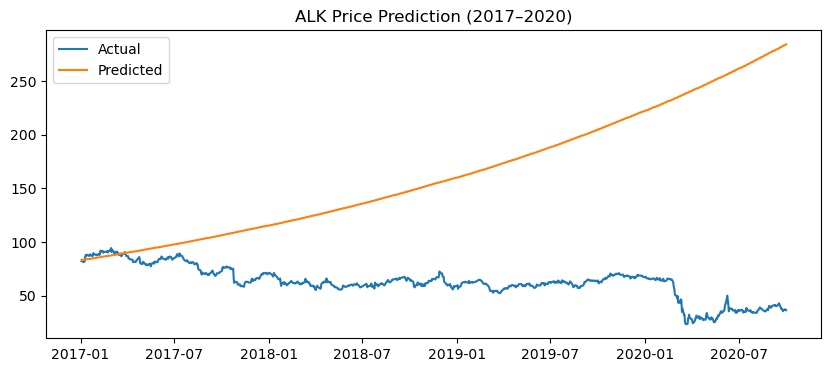

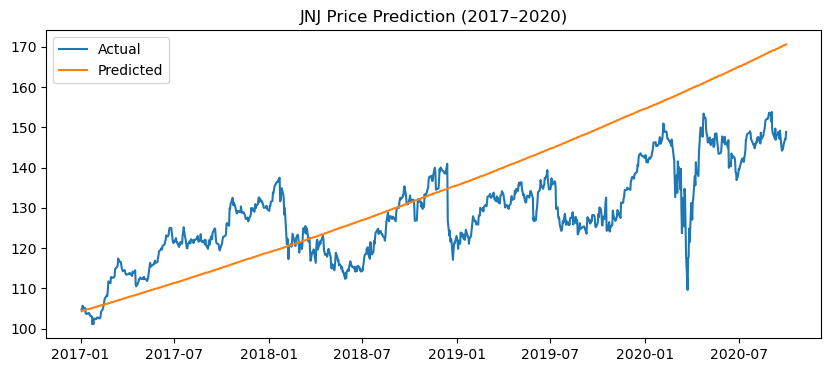

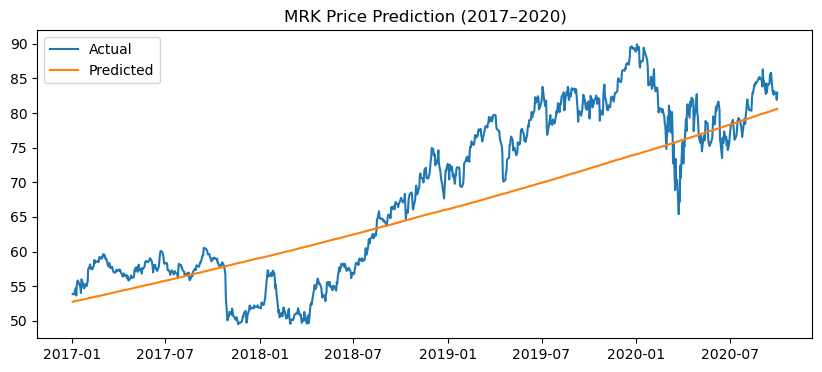

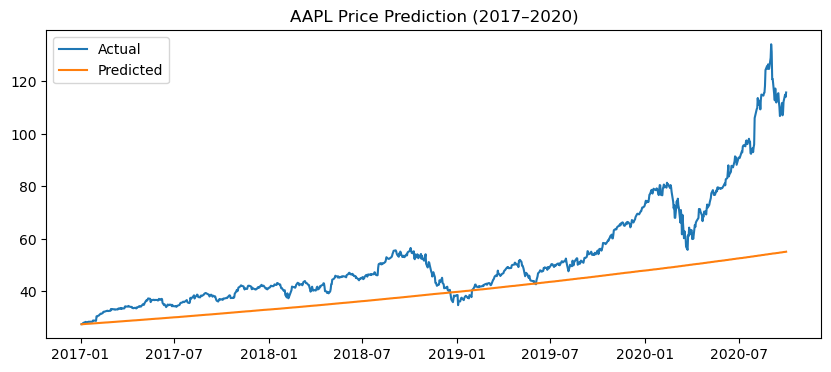

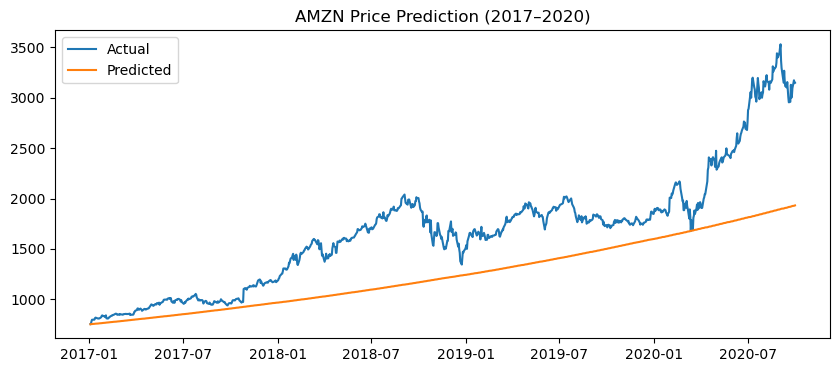

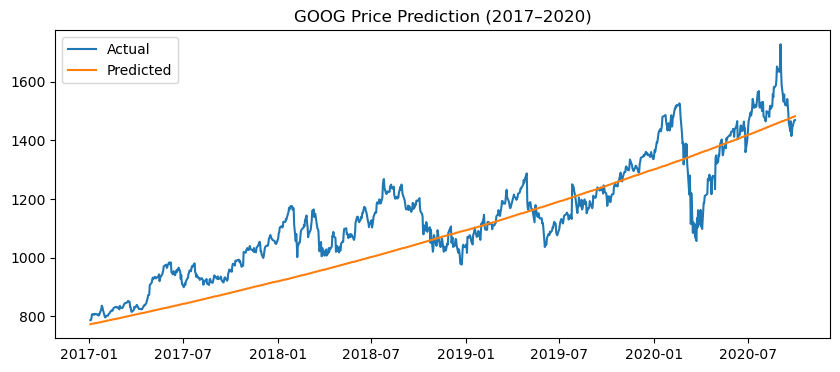

In [74]:
# Predictions for each stock

for col in predicted_prices.columns:
    plt.figure(figsize=(10,4))
    plt.plot(prices.loc['2017':, col], label='Actual')
    plt.plot(predicted_prices[col], label='Predicted')
    plt.title(f'{col} Price Prediction (2017–2020)')
    plt.legend()
    plt.show()

In [75]:
# Computing predicted vs actual portfolio returns

# Equal weights
weights = np.repeat(1/len(selected_stocks), len(selected_stocks))

# Actual portfolio return
actual_port_return = (prices.loc['2017':].pct_change().mean(axis=1) * weights.sum()).mean() * 252
print("Actual Portfolio Annual Return:", actual_port_return.round(3)*100, "%")

# Predicted portfolio return
pred_port_return = (predicted_prices.pct_change().mean(axis=1) * weights.sum()).mean() * 252
print("Predicted Portfolio Annual Return:", pred_port_return.round(3)*100, "%")

Actual Portfolio Annual Return: 20.3 %
Predicted Portfolio Annual Return: 19.8 %


In [76]:
# Predicting future stock prices 2020 October to 2024

In [77]:
# Refitting VAR on full returns data (2010–2020)
full_model = VAR(returns)

# Selecting lag order using AIC
lag_order_results = full_model.select_order(maxlags=10)
selected_order = lag_order_results.aic  # choose AIC
lag_order = max(1, int(selected_order))  # ensure at least 1 lag
print("Using lag order:", lag_order)

# Fitting VAR with chosen lag
var_full = full_model.fit(lag_order)

# Forecast steps = 4 years of trading days (~252 days/year)
forecast_steps = 252 * 4  

# Forecast starting from the last day in your data
forecast_future = var_full.forecast(returns.values[-lag_order:], steps=forecast_steps)

# Creating index starting from next business day after last historical price
forecast_start = returns.index[-1] + pd.Timedelta(days=1)
future_index = pd.bdate_range(start=forecast_start, periods=forecast_steps)  # business days

# Converting forecast to DataFrame
forecast_future_df = pd.DataFrame(forecast_future, index=future_index, columns=returns.columns)

Using lag order: 2


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [78]:
# Making forecast predictions

# Starting from last known price at end of historical data (2020-09-30)
last_prices = prices.iloc[-1]  # last row of prices DataFrame
predicted_future_prices = pd.DataFrame(index=future_index, columns=forecast_future_df.columns)

# Converting forecasted log returns to prices
for col in forecast_future_df.columns:
    pred_vals = [last_prices[col]]  # start from last known price
    for ret in forecast_future_df[col]:
        pred_vals.append(pred_vals[-1] * np.exp(ret))  # inverse log return
    predicted_future_prices[col] = pred_vals[1:]  # drop initial seed


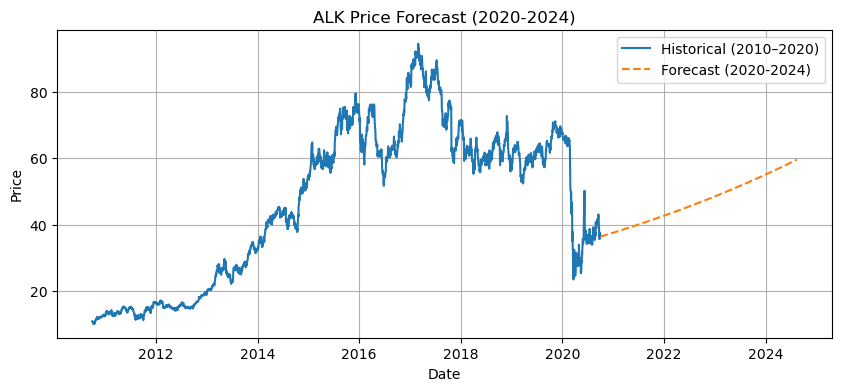

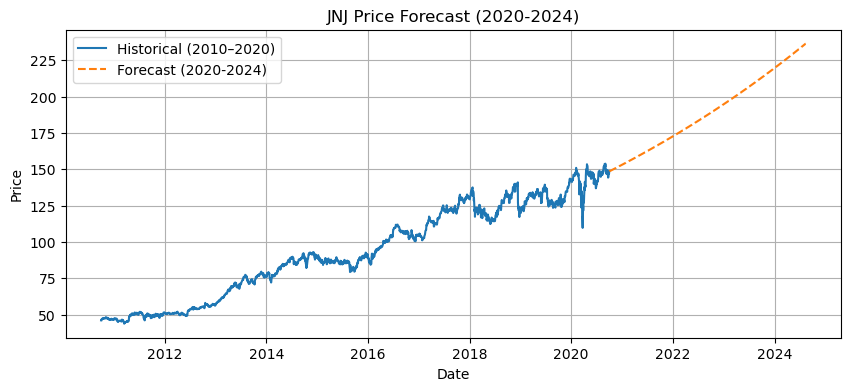

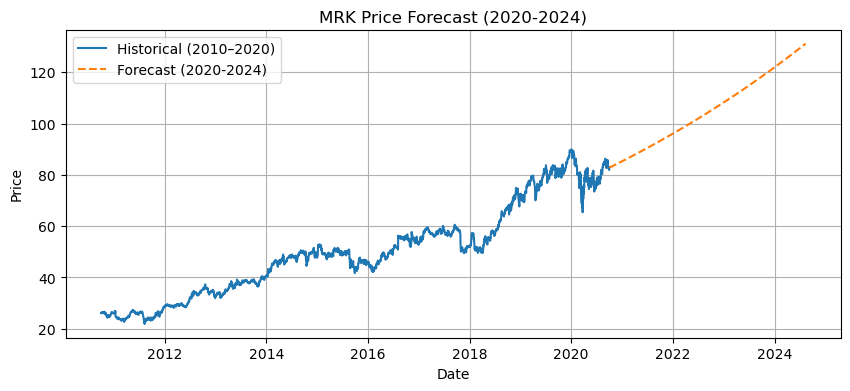

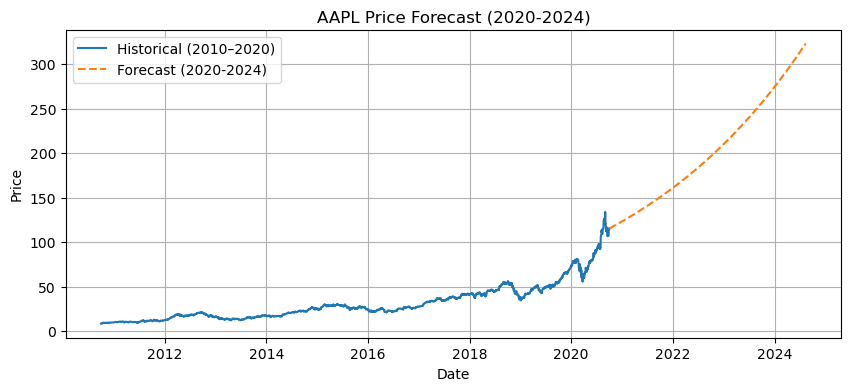

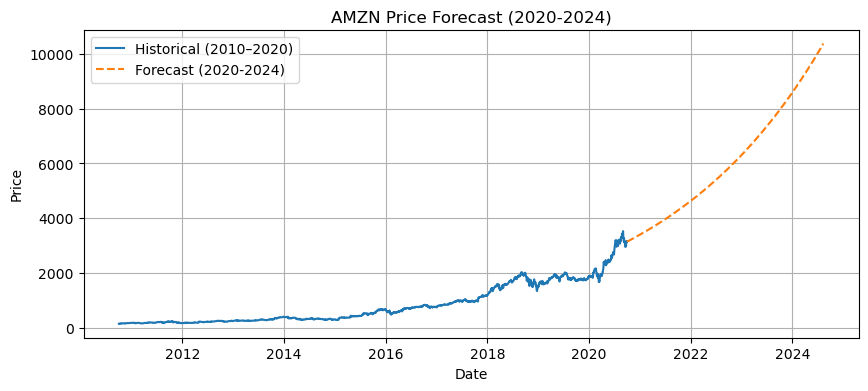

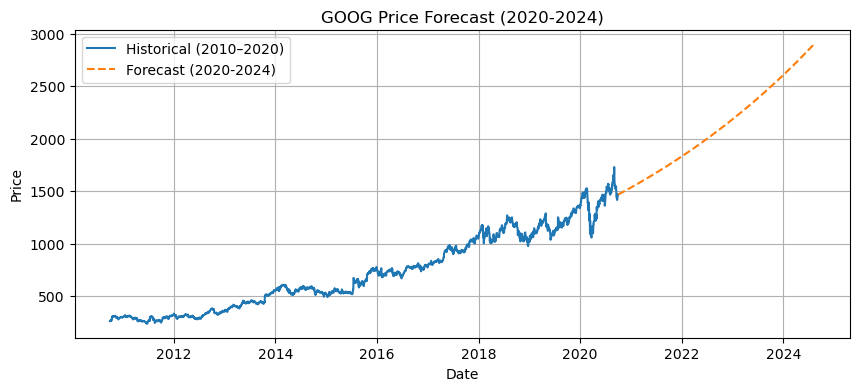

In [79]:
# Plotting the forecast predictions

for col in predicted_future_prices.columns:
    plt.figure(figsize=(10,4))
    
    # Historical prices
    plt.plot(prices[col], label="Historical (2010–2020)")
    
    # Forecasted prices starting from 2020-10-01
    plt.plot(predicted_future_prices[col], label="Forecast (2020-2024)", linestyle="--")
    
    plt.title(f"{col} Price Forecast (2020-2024)")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


In [80]:
# Portfolio Projections

# Equal weights
weights = np.repeat(1/len(selected_stocks), len(selected_stocks))

# Forecasted portfolio returns
forecasted_port_return = (predicted_future_prices.pct_change().mean(axis=1) * weights.sum()).mean() * 252
print("Forecasted Portfolio Annual Return (2021–2024):", forecasted_port_return)

Forecasted Portfolio Annual Return (2021–2024): 0.18015508578734074


#### This suggests that, based on historical patterns and inter-stock relationships captured by VAR, the portfolio could potentially outperform the CAPM expectation.

Forecasted Portfolio Annual Return (2021–2024): 18.016 %


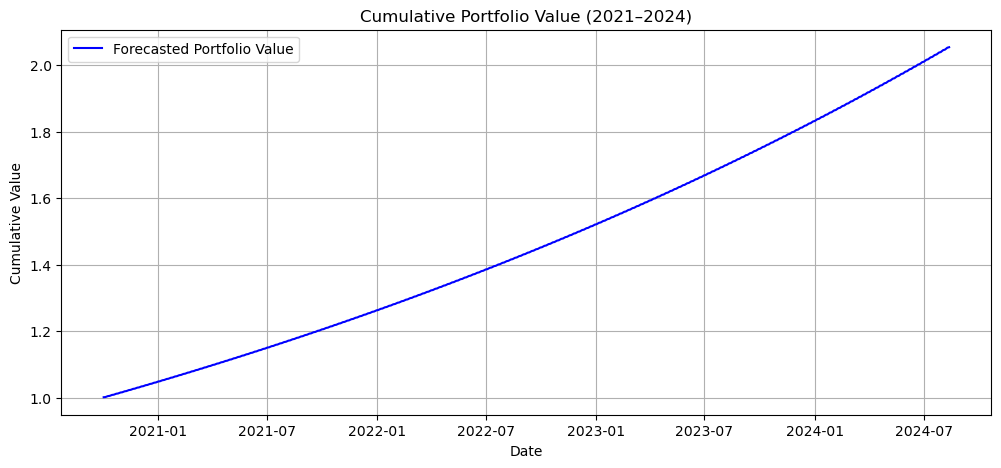

In [82]:
# Plotting cumulative returns for better storytelling

# Equal weights
weights = np.repeat(1/len(predicted_future_prices.columns), len(predicted_future_prices.columns))

# Forecasted portfolio daily returns
portfolio_daily_returns = predicted_future_prices.pct_change().dot(weights)

# Forecasted portfolio annual return
forecasted_port_return = (portfolio_daily_returns.mean()) * 252
print("Forecasted Portfolio Annual Return (2021–2024):", (forecasted_port_return*100).round(3), '%')

# Compute cumulative portfolio value (assuming starting value = 1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Plot cumulative portfolio value
plt.figure(figsize=(12,5))
plt.plot(portfolio_cumulative, color='blue', label='Forecasted Portfolio Value')
plt.title("Cumulative Portfolio Value (2021–2024)")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend()
plt.show()

### Inference

- Projected growth: ~100% cumulative growth over 4 years.

- Trend over time: The portfolio value grows exponentially, consistent with an annual return of ~18%.

- Portfolio validation: The portfolio's expected performance will be able to help our client achieve her goals.

In [144]:
### Final Portfolio

final_portfolio_df = capm_df[capm_df["Weighted Score"] > 50]
final_portfolio_df = final_portfolio_df.reset_index().rename(columns={"index": "Ticker"})

# Extracting company details to merge with final portfolio stocks
company_info_df = stock_analysis_dataset_raw[["Ticker", "Company Name", "Industry"]].drop_duplicates()

# Merge with our final portfolio
final_portfolio_with_info = (
    final_portfolio_df.reset_index()
    .merge(company_info_df, on="Ticker", how="left"))

# Reorder columns for readability
final_portfolio_with_info = final_portfolio_with_info[
    ["Ticker", "Company Name", "Industry", "Beta", "CAPM Exp Annual", 
     "Actual Annual", "Jensen Alpha Annual", "Volatility Annual", 
     "Sharpe Ratio", "Weighted Score"]]

final_portfolio_with_info = final_portfolio_with_info.drop(columns=["Ticker"])

In [150]:
final_portfolio_with_info

,Company Name,Industry,Beta,CAPM Exp Annual,Actual Annual,Jensen Alpha Annual,Volatility Annual,Sharpe Ratio,Weighted Score
0,Amazon,Technology,1.00,0.13,0.42,0.26,0.32,1.31,92.51
1,Apple Inc,Technology,1.06,0.14,0.35,0.18,0.28,1.21,82.36
2,Alphabet,Technology,1.01,0.13,0.23,0.09,0.26,0.86,65.74
3,Johnson & Johnson,Healthcare,0.66,0.09,0.14,0.05,0.17,0.78,63.46
4,Merck and CO inc.,Healthcare,0.74,0.10,0.15,0.05,0.21,0.68,60.41
5,Alaska Air Group Inc,Aviation,1.23,0.16,0.21,0.04,0.37,0.55,52.61


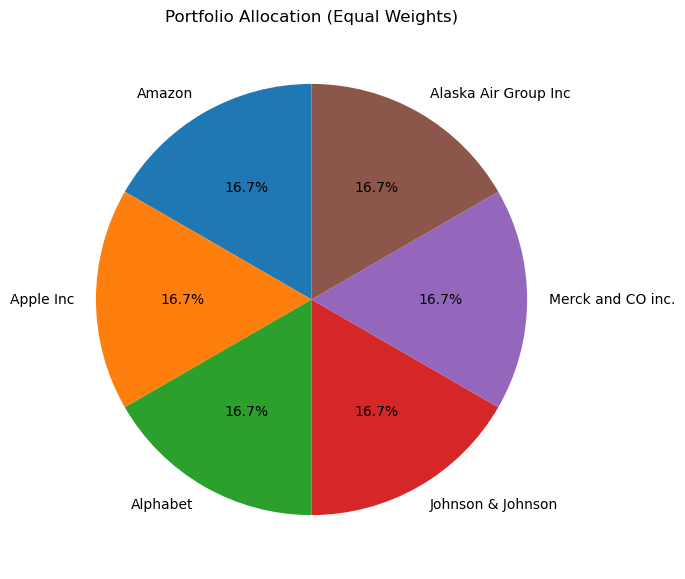

In [148]:
# Pie chart with equal weights
labels = final_portfolio_with_info["Company Name"]
sizes = [1/len(final_portfolio_with_info)] * len(final_portfolio_with_info)

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Portfolio Allocation (Equal Weights)")
plt.show()

# <font color = Dark> _End_

--------